# Project Outline

The goal of this project is to assess how well different measures of volatility capture the true volatility dynamics of ETH/USDT. Using klines and options data from Binance Vision, I compare GARCH volatility forecasts and implied volatility from the ETH/USDT options market with forward realised volatility over rolling 1-day windows.

The comparison is motivated by Chi and Hao (2021)<sup>[1]</sup>, who find GARCH to outperform options IV and build a successful trading strategy on what they describe as inefficiency in the options pricing market during their sample period. In their conclusion, they state that future research could monitor the cryptocurrency options market to investigate whether pricing efficiency improves as institutional market participants enter the space. Their comparison sample period is from 10 September 2019 to 26 March 2020, whereas my comparison sample period is from 18 May 2023 to 23 October 2023. Therefore I test whether their findings extend to my sample period for ETH/USDT.

I find that neither GARCH nor IV provides any material forecasting power on 1-day forward realised volatility over my primary forecast window (both with adjusted $R^2$ near 0). However, extending the methodology of Chi and Hao to include significance testing of forecast accuracy using QLIKE, a loss-based measure, I find that IV significantly outperforms GARCH (Diebold-Mariano statistic 3.56, p < 0.01). Since the IV series is derived from a long-dated contract (following their methodology), part of this outperformance may reflect the horizon mismatch rather than superior 1-day forecasting. The outperformance of IV contrasts with the main findings of Chi and Hao.

Given the relatively flat volatility over my sample period, I conduct a sensitivity test for GARCH using a more volatile 365-day forecasting period in which I find GARCH to provide stronger results (adjusted $R^2$ of 0.29). This result suggests that my primary results may be a function of the relatively non-volatile sample period rather than a change in GARCH's ability to forecast forward realised volatility. Further, this result is in line with that of Chi and Hao (2021) in their longer Binance forecasting period, where they get an adjusted $R^2$ of 0.32. Due to data constraints I was not able to compare IV over the same volatile 365-day window, and am therefore unable to conclude on whether market efficiency has improved.

Further possible avenues of interest for this project include comparing suitability of the different GARCH variants used by Chi and Hao, such as GJR-GARCH; fitting my own volatility surface rather than relying on mark_iv provided by Binance and/or constructing a constant-maturity short-dated IV series to reduce the horizon mismatch; further investigating the drivers of the GARCH models' convergence to IGARCH; and acquiring new data to compare IV's forecasting ability over a more volatile window, allowing an assessment of any change in market efficiency.

---
<sup>[1]</sup> Chi, Y., & Hao, W. (2021). Volatility models for cryptocurrencies and applications in the options market. *Journal of International Financial Markets, Institutions & Money, 75,* 101421.

I first import the necessary libraries for my analysis:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
from arch import arch_model
import sys
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
import calplot

In [2]:
# I adjust the option for maximum displayed columns to be None, so that all columns are displayed in the output.
pd.set_option("display.max_columns", None)

# Importing Data and Initial Cleaning

To run this notebook yourself, the referenced data from Binance (linked in the "Klines Data" and "Options Data" sections below) is required, with a parent folder "binance_raw" stored in the same location as this .ipynb file containing two subfolders: "binance_ethusdt_5m" containing the 5 minute klines data, and "Options" containing the end of hour summary options data.

## Klines Data

Here, I create the klines_df using ETH/USDT klines data at a 5 minute frequency, downloaded from Binance Vision for all dates from 1 May 2020 to 15 February 2026 (https://data.binance.vision/?prefix=data/spot/daily/klines/ETHUSDT/5m/).

I then perform initial data cleaning, including identifying missing values and converting time variables to datetime values.

In [3]:
cols = [
    "open_time",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "close_time",
    "quote_volume",
    "num_trades",
    "taker_buy_base_volume",
    "taker_buy_quote_volume",
    "ignore"
]

In [4]:
# Concatenate downloaded files into a dataframe
files = sorted(Path("binance_raw/binance_ethusdt_5m").glob("ETHUSDT-5m-*.csv"))

klines_df = pd.concat(
    (
        pd.read_csv(f, header=None, names=cols)
        for f in files
    ),
    ignore_index=True
)

klines_df.head()

,open_time,open,high,low,close,volume,close_time,quote_volume,num_trades,taker_buy_base_volume,taker_buy_quote_volume,ignore
0,1588291200000,206.07,207.59,205.91,207.14,4446.34186,1588291499999,9.199316e+05,1907,2335.67662,483183.336644,0
1,1588291500000,207.15,207.96,207.04,207.87,3009.61806,1588291799999,6.243115e+05,1272,1568.15253,325199.679470,0
2,1588291800000,207.82,208.21,207.39,207.93,4508.51938,1588292099999,9.370988e+05,1347,1404.21005,291787.551787,0
3,1588292100000,207.94,209.00,207.94,208.33,6329.66094,1588292399999,1.319894e+06,2188,3546.05170,739344.614251,0
4,1588292400000,208.32,208.73,207.35,208.72,2905.22126,1588292699999,6.043129e+05,1137,1699.80399,353580.575718,0


In [5]:
# View data types and check for missing values
klines_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 609367 entries, 0 to 609366
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   open_time               609367 non-null  int64  
 1   open                    609367 non-null  float64
 2   high                    609367 non-null  float64
 3   low                     609367 non-null  float64
 4   close                   609367 non-null  float64
 5   volume                  609367 non-null  float64
 6   close_time              609367 non-null  int64  
 7   quote_volume            609367 non-null  float64
 8   num_trades              609367 non-null  int64  
 9   taker_buy_base_volume   609367 non-null  float64
 10  taker_buy_quote_volume  609367 non-null  float64
 11  ignore                  609367 non-null  int64  
dtypes: float64(8), int64(4)
memory usage: 55.8 MB


In [6]:
# Check numerical variables to identify any unexpected values
klines_df.describe()

,open_time,open,high,low,close,volume,close_time,quote_volume,num_trades,taker_buy_base_volume,taker_buy_quote_volume,ignore
count,6.093670e+05,609367.000000,609367.000000,609367.000000,609367.000000,609367.000000,6.093670e+05,6.093670e+05,609367.000000,609367.000000,6.093670e+05,609367.0
mean,3.419414e+14,2287.783755,2291.086449,2284.405808,2287.786188,2149.671596,3.419414e+14,4.463796e+06,5777.084289,1068.473572,2.217716e+06,0.0
std,6.930560e+14,1099.250601,1100.755536,1097.697317,1099.247415,3083.711370,6.930561e+14,6.752516e+06,8978.857477,1555.657087,3.409947e+06,0.0
min,1.588291e+12,178.800000,181.100000,176.000000,178.800000,0.000000,1.588291e+12,0.000000e+00,0.000000,0.000000,0.000000e+00,0.0
25%,1.634088e+12,1605.000000,1607.220000,1602.540000,1604.990000,655.848300,1.634088e+12,1.191136e+06,1471.000000,310.917900,5.630233e+05,0.0
50%,1.679795e+12,2247.640000,2250.760000,2244.460000,2247.640000,1241.518800,1.679795e+12,2.520011e+06,2801.000000,608.525800,1.229037e+06,0.0
75%,1.725497e+12,3122.690000,3126.770000,3118.695000,3122.680000,2435.999150,1.725498e+12,5.096903e+06,6292.000000,1215.126850,2.531604e+06,0.0
max,1.771200e+15,4951.500000,4956.780000,4943.160000,4951.500000,145838.039100,1.771200e+15,3.001951e+08,686634.000000,72842.633800,1.500666e+08,0.0


In [7]:
# Identify higher open times, which need to be adjusted to convert all times to milliseconds
klines_df.sort_values("open_time", ascending=False).head()

,open_time,open,high,low,close,volume,close_time,quote_volume,num_trades,taker_buy_base_volume,taker_buy_quote_volume,ignore
609366,1771199700000000,1965.53,1967.36,1965.53,1966.58,595.3619,1771199999999999,1.170556e+06,7903,338.8593,6.662107e+05,0
609365,1771199400000000,1962.54,1968.01,1962.54,1965.53,1282.1114,1771199699999999,2.520403e+06,13940,777.7634,1.529127e+06,0
609364,1771199100000000,1962.35,1964.91,1962.19,1962.53,621.9772,1771199399999999,1.221171e+06,14072,356.9368,7.007531e+05,0
609363,1771198800000000,1958.50,1962.56,1958.50,1962.36,677.6733,1771199099999999,1.328706e+06,9581,404.4909,7.930794e+05,0
609362,1771198500000000,1962.33,1963.38,1958.49,1958.49,814.8809,1771198799999999,1.597643e+06,8671,285.9983,5.607630e+05,0


In [8]:
# Divide microsecond times by 1000 to ensure all close_time values are in milliseconds
klines_df["open_time"] = np.where(klines_df["open_time"] > 2000000000000, klines_df["open_time"]/1000, klines_df["open_time"])

# Check that all close_time value are now in milliseconds
klines_df["open_time"].describe()

count    6.093670e+05
mean     1.679779e+12
std      5.279466e+10
min      1.588291e+12
25%      1.634088e+12
50%      1.679795e+12
75%      1.725497e+12
max      1.771200e+12
Name: open_time, dtype: float64

Next, I identify missing values.

In [9]:
# Convert open_time column to pd datetime
klines_df["open_time"] = pd.to_datetime(klines_df["open_time"], unit="ms", utc=True)

# Set the index
klines_df = klines_df.set_index("open_time")

In [10]:
# Generate a series containing all 5 minute periods from start to end of the binance data
all_times = pd.date_range(start=klines_df.index[0], end=klines_df.index[-1], freq="5min", tz="UTC")

# Keep a copy of klines_df
klines_old_df = klines_df.copy()

# Re-index on the full time series
klines_df = klines_df.reindex(all_times)

# Name the index
klines_df.index.name = "open_time"

(<Figure size 1800x1200 with 7 Axes>,
 array([<Axes: ylabel='2020'>, <Axes: ylabel='2021'>,
        <Axes: ylabel='2022'>, <Axes: ylabel='2023'>,
        <Axes: ylabel='2024'>, <Axes: ylabel='2025'>,
        <Axes: ylabel='2026'>], dtype=object))

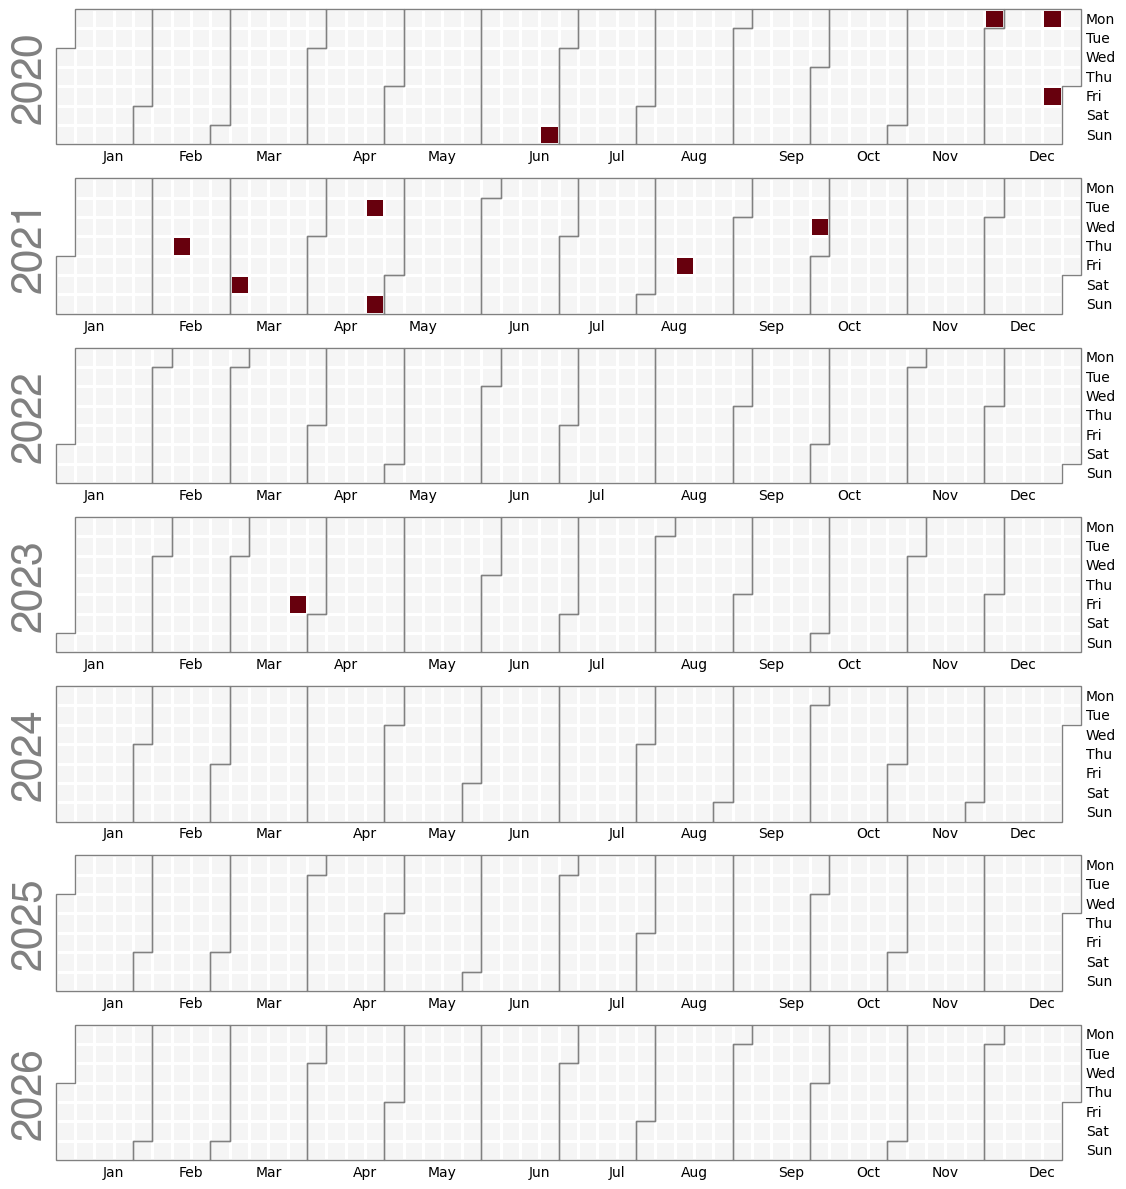

In [11]:
missing = klines_df["close"].isna()
calplot.calplot(missing.tz_convert(None), cmap="Reds", colorbar=False, vmin=0, vmax=2, figsize=(18,12))

In [12]:
# Identify frequency and duration of gaps
gaps_df = klines_old_df.index.to_series().diff().value_counts().sort_index()
gaps_df

open_time
0 days 00:05:00    609355
0 days 01:05:00         2
0 days 01:20:00         1
0 days 01:25:00         1
0 days 01:35:00         1
0 days 02:05:00         1
0 days 02:35:00         1
0 days 03:35:00         1
0 days 04:15:00         1
0 days 04:35:00         1
0 days 04:45:00         1
Name: count, dtype: int64

In [13]:
gaps_df.iloc[1:].reset_index()["open_time"].mean()

Timedelta('0 days 02:43:30')

I have identified 11 gaps in this dataset, with a mean duration of 2 hours, 43 minutes, and 30 seconds. I do not expect this to impact my results in any material way.

## Options Data

Here, I create the options_df using ETH/USDT options data provided as an end-of-hour summary, downloaded from Binance Vision for all dates available, being 18 May 2023 to 23 October 2023 (https://data.binance.vision/?prefix=data/option/daily/EOHSummary/ETHUSDT/).

I then perform initial data cleaning, including identifying missing values and converting time variables to datetime values.

In [14]:
# Generate file paths to include
files = Path("binance_raw/Options").glob("*")
good_files = []

for f in files:
    if "CHECKSUM" in f.name:
        continue
    good_files.append(f)

In [15]:
# Concatenate downloaded files into a dataframe
options_df = pd.concat(
    (
        pd.read_csv(f)
        for f in good_files
    ),
    ignore_index=True
)

options_df.head()

,date,hour,symbol,underlying,type,strike,open,high,low,close,volume_contracts,volume_usdt,best_bid_price,best_ask_price,best_bid_qty,best_ask_qty,best_buy_iv,best_sell_iv,mark_price,mark_iv,delta,gamma,vega,theta,openinterest_contracts,openinterest_usdt
0,2023-05-27,0,ETH-230527-1875-P,ETHUSDT,P,230527-1875,112.0,112.0,35.4,35.4,1.26,1.26,44.0,57.7,30.00,30.00,NaN,1.278706,50.9,0.789353,-0.877919,0.004968,0.104540,-14.145565,49.16,8.978420e+04
1,2023-05-27,0,ETH-230630-2000-C,ETHUSDT,C,230630-2000,34.3,35.3,30.8,35.3,38.87,38.87,35.6,36.7,250.00,19.17,NaN,0.430332,36.1,0.427334,0.265153,0.001370,1.834218,-1.142877,215.83,3.941849e+05
2,2023-05-27,0,ETH-230929-2000-C,ETHUSDT,C,230929-2000,125.0,125.0,125.0,125.0,0.00,0.00,126.4,140.4,24.37,31.00,NaN,0.485390,133.3,0.468683,0.423370,0.000781,4.190053,-0.783694,221.81,4.051064e+05
3,2023-05-27,1,ETH-230602-2000-C,ETHUSDT,C,230602-2000,3.6,4.1,2.5,4.1,274.48,274.48,2.8,3.4,0.16,13.67,NaN,0.455061,3.0,0.445461,0.067474,0.001224,0.312542,-1.113800,668.77,1.223815e+06
4,2023-05-27,1,ETH-230609-1500-C,ETHUSDT,C,230609-1500,0.0,0.0,0.0,0.0,0.00,0.00,313.5,350.8,17.25,18.08,NaN,0.953341,333.9,0.626670,0.957744,0.000412,0.314129,-0.742850,0.00,0.000000e+00


In [16]:
options_df["expiry"] = pd.to_datetime(options_df["symbol"].str[4:10], format="%y%m%d", utc=True) + pd.Timedelta(hours=8)
options_df["strike"] = options_df["strike"].str.split("-", expand=True)[1].astype(float)
options_df["timestamp"] = (pd.to_datetime(options_df["date"]) + pd.to_timedelta(options_df["hour"], unit="h")).dt.tz_localize("UTC")
options_df["maturity"] = options_df["expiry"] - options_df["timestamp"]
options_df.describe()

,hour,strike,open,high,low,close,volume_contracts,volume_usdt,best_bid_price,best_ask_price,best_bid_qty,best_ask_qty,best_buy_iv,best_sell_iv,mark_price,mark_iv,delta,gamma,vega,theta,openinterest_contracts,openinterest_usdt,maturity
count,979331.000000,979331.000000,979331.000000,979331.000000,979331.000000,979331.000000,979331.000000,979331.000000,979331.000000,9.793310e+05,979331.000000,979331.000000,0.0,9.793310e+05,979331.000000,979331.000000,979331.000000,979331.000000,979331.000000,979331.000000,972799.000000,9.727990e+05,979331
mean,11.490634,2089.445212,168.906958,170.880333,166.853328,168.621456,40.672423,40.672423,214.912600,6.531652e+02,36.218668,37.652976,NaN,1.097310e+00,345.349790,0.572419,-0.054981,0.001099,1.623469,-1.074912,256.464970,4.454483e+05,87 days 11:47:11.801301
std,6.920431,964.453044,324.083031,323.948304,324.193067,324.107557,165.096032,165.096032,457.631691,4.414112e+04,65.904981,59.530672,NaN,1.509040e+00,650.935355,0.204582,0.620770,0.004393,1.766152,22.027007,466.708086,7.974867e+05,98 days 23:22:43.978431
min,0.000000,0.059000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,NaN,-1.000000e-08,0.100000,0.000000,-1.000000,0.000000,0.000000,-8840.661523,0.000000,0.000000e+00,-11 days +02:00:00
25%,5.000000,1600.000000,1.500000,1.700000,1.000000,1.100000,0.000000,0.000000,5.300000,9.500000e+00,10.620000,15.000000,NaN,4.478312e-01,12.400000,0.421232,-0.629532,0.000195,0.244015,-1.000999,0.050000,9.250703e+01,8 days 23:00:00
50%,11.000000,1900.000000,30.500000,33.700000,27.000000,30.000000,0.000000,0.000000,51.600000,8.890000e+01,23.540000,23.730000,NaN,5.791211e-01,101.000000,0.519877,0.000000,0.000481,0.914364,-0.555242,47.830000,8.393219e+04,43 days 21:00:00
75%,17.000000,2300.000000,191.900000,195.000000,187.400000,191.900000,6.530000,6.530000,245.200000,4.035000e+02,31.000000,32.000000,NaN,9.438539e-01,403.100000,0.700000,0.371391,0.001087,2.516863,-0.294547,312.160000,5.527122e+05,148 days 16:00:00
max,23.000000,7500.000000,2884.300000,2884.300000,2884.300000,2884.300000,5812.270000,5812.270000,5540.000000,1.000000e+07,2034.430000,2001.000000,NaN,9.999999e+00,5971.500000,1.800000,1.000000,1.276810,7.895625,0.000000,5991.370000,9.561314e+06,365 days 00:00:00


Next, I check whether there are any missing dates. I expect several missing dates in September due to their unavailability on Binance vision (https://data.binance.vision/?prefix=data/option/daily/EOHSummary/ETHUSDT/), however I still check to see whether there are further missing dates.

In [17]:
options_dates = pd.to_datetime(options_df["date"]).unique()
full_dates = pd.date_range(start=options_df["timestamp"].min().date(), end=options_df["timestamp"].max().date(), freq="D")
missing_dates = full_dates.difference(options_dates)

There are 12 missing dates.


(<Figure size 1800x1200 with 1 Axes>,
 array([<Axes: ylabel='2023'>], dtype=object))

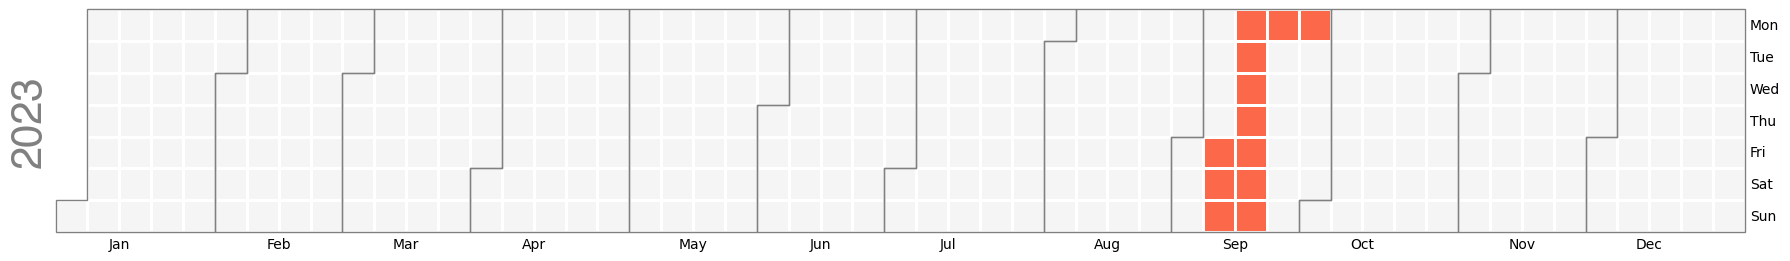

In [18]:
missing_date_series = pd.Series([date in missing_dates for date in full_dates], index=full_dates)
print(f"There are {len(missing_dates)} missing dates.")
calplot.calplot(missing_date_series, cmap="Reds", colorbar=False, vmin=0, vmax=2, figsize=(18,12))

The calendar plot above highlights missing dates from the options dataframe in red. These dates are the same as those missing from Binance vision, meaning I have all the dates that I would have expected to have.

## Analysis

First, I analyse the klines dataset to produce an annualised 1-day forward realised volatility time series.

In [19]:
# Calculate log returns and drop first row
klines_df["return"] = np.log(klines_df["close"]).diff()
klines_df.dropna(subset=["return"], inplace=True)
klines_df.head()

,open,high,low,close,volume,close_time,quote_volume,num_trades,taker_buy_base_volume,taker_buy_quote_volume,ignore,return
open_time,,,,,,,,,,,,
2020-05-01 00:05:00+00:00,207.15,207.96,207.04,207.87,3009.61806,1.588292e+12,6.243115e+05,1272.0,1568.15253,325199.679470,0.0,0.003518
2020-05-01 00:10:00+00:00,207.82,208.21,207.39,207.93,4508.51938,1.588292e+12,9.370988e+05,1347.0,1404.21005,291787.551787,0.0,0.000289
2020-05-01 00:15:00+00:00,207.94,209.00,207.94,208.33,6329.66094,1.588292e+12,1.319894e+06,2188.0,3546.05170,739344.614251,0.0,0.001922
2020-05-01 00:20:00+00:00,208.32,208.73,207.35,208.72,2905.22126,1.588293e+12,6.043129e+05,1137.0,1699.80399,353580.575718,0.0,0.001870
2020-05-01 00:25:00+00:00,208.71,209.09,208.16,208.65,3445.83924,1.588293e+12,7.189948e+05,1285.0,1408.09204,293864.357892,0.0,-0.000335


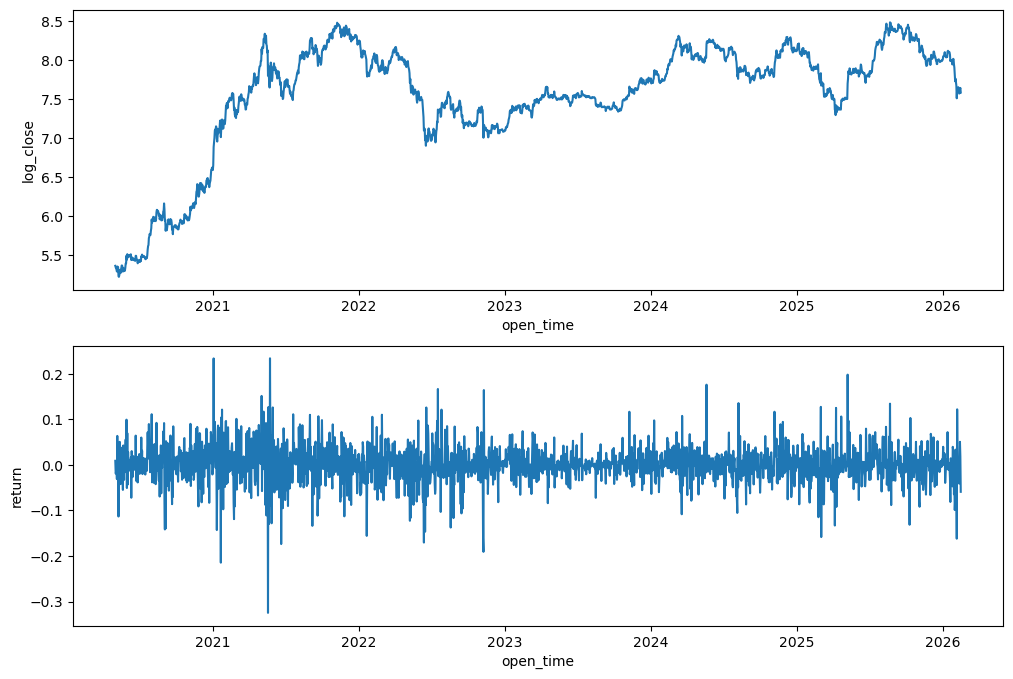

In [20]:
# Resample to daily for plots and later GARCH analysis
daily_klines_df = klines_df.resample("D").agg({"close": "last"})

# Because of missing values, daily returns cannot be calculated by summing 5-minute returns. Instead, need to recalculate:
daily_klines_df["log_close"] = np.log(daily_klines_df["close"])
daily_klines_df["return"] = daily_klines_df["log_close"].diff()
daily_klines_df = daily_klines_df.dropna(subset=["return"])

# Plot prices and returns
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12,8))

sns.lineplot(data=daily_klines_df, x="open_time", y="log_close", ax=axes[0])

sns.lineplot(data=daily_klines_df, x="open_time", y="return", ax=axes[1])

plt.show()

Given that I previously identified missing values, I check how many rolling 1-day windows are affected.

In [21]:
returns = klines_df["return"]

# Identify missing rolling windows
counts = returns.rolling("1D").count()
counts.describe()

count    609355.000000
mean        287.782884
std           4.319562
min           1.000000
25%         288.000000
50%         288.000000
75%         288.000000
max         288.000000
Name: return, dtype: float64

In [22]:
# Count number of rolling windows which are incomplete as a percentage of total
print(f"Percentage of rolling windows which are incomplete: {100*len(counts[counts<288]) / len(counts):.2f}%")

Percentage of rolling windows which are incomplete: 0.57%


Given how small this percentage is, I elect to maintain a strict minimum period criterion for calculating the 1-day realised volatility, being exactly the number of 5 minute periods in 24 hours (12 x 24 = 288).

In [23]:
# Calculate 1-day rolling realised volatility
realised_vol_1d = np.sqrt((returns**2).rolling("1D", min_periods=288).sum())

# Annualise it
realised_vol_1d_annual = realised_vol_1d * np.sqrt(365)

# Resample to daily values
realised_vol_1d_annual = realised_vol_1d_annual.resample("D").last()

# Convert to forward-looking measure
fwd_realised_vol_1d_annual = realised_vol_1d_annual.shift(-1).rename("1-day Forward Realised Volatility Annualised")

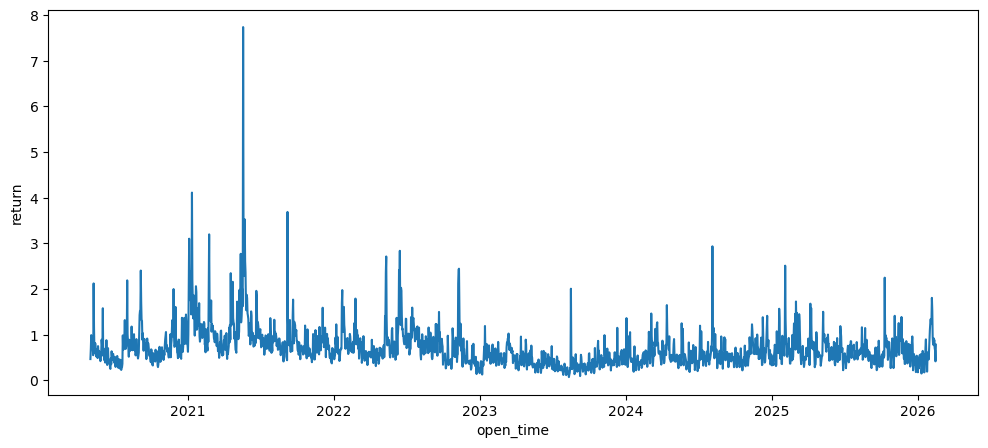

In [24]:
# Plot realised volatility
fig, axes = plt.subplots(figsize=(12,5))

sns.lineplot(data=realised_vol_1d_annual)

plt.show()

# GARCH Model

The Generalised Autoregressive Conditional Heteroskedasticity (GARCH) model was introduced by Bollerslev (1986)<sup>[2]</sup>, as an extension of the Autoregressive Conditional Heteroskedasticity model introduced by Engle (1982)<sup>[3]</sup>. The ARCH model proved useful in modelling several different economic phenomena by relaxing the typical requirement in previous time series models for homoskedasticity. It does this by separating unconditional and conditional variance, where the latter is allowed to change over time as a function of past errors.

As set out in Bollerslev (1986), let $\varepsilon_t$ denote a real-valued discrete-time stochastic process, and $\psi_t$, the information set of all information through time *t*. An ARCH(q) model is then given by:

$$
\varepsilon_t \mid \psi_{t-1} \sim N(0, h_t)
$$
$$
h_t = \alpha_0 + \sum_{i=1}^{q} \alpha_i \varepsilon_{t-i}^2
$$
where
$$
q > 0, \quad \alpha_0 > 0, \quad \alpha_i \geq 0, \quad i = 1,\ldots,q.
$$

The GARCH model introduces a third term to the conditional variance, $h_t$, being its own lagged conditional variance term, $h_{t-1}$. A GARCH(p,q) model is given by:

$$
h_t = \alpha_0 + \sum_{i=1}^{q} \alpha_i \varepsilon_{t-i}^2 + \sum_{i=1}^{p} \beta_i h_{t-i}
$$
where
$$
p \geq 0, \quad q > 0, \quad \alpha_0 > 0, \quad \alpha_i \geq 0, \quad i = 1,\ldots,q, \quad \beta_i \geq 0, \quad i = 1,\ldots,p.
$$

---
<sup>[2]</sup> Bollerslev, T. (1986). Generalized autoregressive conditional heteroskedasticity. *Journal of Econometrics, 31*(3), 307-327.

<sup>[3]</sup> Engle, R. F. (1982). Autoregressive conditional heteroscedasticity with estimates of the variance of United Kingdom inflation. *Econometrica, 50*(4), 987-1008.

## Pre-fit diagnostic tests

First, I truncate the daily_klines_df to exclude data from the beginning of the options_df onwards, since this will be the period I look at for forecasts and would otherwise bias my results.

In [25]:
cutoff = options_df["timestamp"].min() - pd.Timedelta(days=1)

daily_returns = daily_klines_df[:cutoff]["return"]
daily_prices = daily_klines_df[:cutoff]["log_close"]

### Stationarity

I conduct the augmented Dickey-Fuller test on the log price series at the 5% significance level to test for a unit root (log prices since I will be using log returns). The test takes a unit root as its null hypothesis (i.e. shocks to the series do not decay), meaning the coefficient of the lagged price term in the autoregressive model is hypothesised to be 0 (where rejection is consistent with the series being stationary). The test "augments" the simple Dickey-Fuller test by introducing a new term, which is the sum of prior differenced terms (i.e. $\sum_{i=1}^{p} \delta_i \Delta y_{t-i}$). This relaxes the assumption made by the simple Dickey-Fuller test that errors are white noise, instead allowing for autocorrelation in the residuals.

In [26]:
adf_result = adfuller(daily_prices)
print(f"ADF Statistic: {adf_result[0]:.2f}")
print(f"p-value: {adf_result[1]:.2f}")
print(f"Critical Values: {adf_result[4]}")

ADF Statistic: -2.49
p-value: 0.12
Critical Values: {'1%': np.float64(-3.4363087505882794), '5%': np.float64(-2.864171074710744), '10%': np.float64(-2.5681708669421486)}


With a p-value of 0.12, I fail to reject the null, suggesting that the series has a unit root.

I also perform a KPSS test. The KPSS test essentially flips the hypotheses from the augmented Dickey-Fuller test (i.e. null hypothesis: series is stationary, alternative hypothesis: unit root).

In [27]:
kpss_result = kpss(daily_prices, regression ="c", nlags="auto")
print(f"KPSS Statistic: {kpss_result[0]:.2f}")
print(f"p-value: {kpss_result[1]}")
print(f"Critical Values: {kpss_result[3]}")

KPSS Statistic: 2.28
p-value: 0.01
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


/var/folders/p3/w_r6vrgd2db2s40r1pc4hq0r0000gn/T/ipykernel_44157/38128482.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(daily_prices, regression ="c", nlags="auto")


The KPSS Statistic far exceeds the 1% critical value of 0.739, so I reject the null and conclude that the series is non-stationary and is instead an I(1) series. Differencing an I(1) series should result in a stationary series, so I conduct the augmented Dickey-Fuller test on the log returns series to test for stationarity.

In [28]:
adf_result = adfuller(daily_returns)
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")
print(f"Critical Values: {adf_result[4]}")

ADF Statistic: -9.88945188207057
p-value: 3.590290603426435e-17
Critical Values: {'1%': np.float64(-3.4363033257654716), '5%': np.float64(-2.864168681767248), '10%': np.float64(-2.568169592476825)}


The ADF Statistic is far below the 1% critical value of -3.44, so I reject the null at the 5% significance level as the evidence is consistent with stationarity. 

Taken together, these results show that the log price series is I(1) and the log return series is I(0), confirming that taking the first difference of the log price series is sufficient to achieve stationarity.

### Autocorrelation

I now conduct Ljung-Box tests at the 5% significance level on the returns series to test for autocorrelation. The null hypothesis of this test is that the series is white noise, i.e. that no lagged return $r_{t-k}$ is correlated with $r_t$ for lags $k=1,\ldots,m$, with the alternative hypothesis being that at least one $r_{t-k}$ is correlated with $r_t$. Conventionally, lags of 5, 10, and 20 are often used for equities to represent roughly 1 week, 2 weeks, and 1 month. Given that crypto trades 24/7, I use lags of 7, 14, and 30 to capture analogous periods.

In [29]:
acorr_ljungbox(daily_returns, lags=[7, 14, 30], return_df=True)

,lb_stat,lb_pvalue
7,14.360060,0.045136
14,31.956623,0.004063
30,45.561272,0.034199


The results of the Ljung-Box test indicate that for each of the lags I used, the null is rejected at the 5% significance level. This is somewhat unexpected since, under the weak-form of the efficient market hypothesis, daily returns should not be predictable from their own past returns, i.e. on their face, these results suggest some market inefficiency. To visually inspect where these dependencies lie and their magnitudes, I plot the autocorrelation function and partial autocorrelation function.

In [30]:
# Define a function for plotting of ACF and PACF
def acf_pacf_plots(series, lags=30):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

    plot_acf(series, lags=lags, ax=axes[0])

    plot_pacf(series, lags=lags, ax=axes[1])

    plt.show()

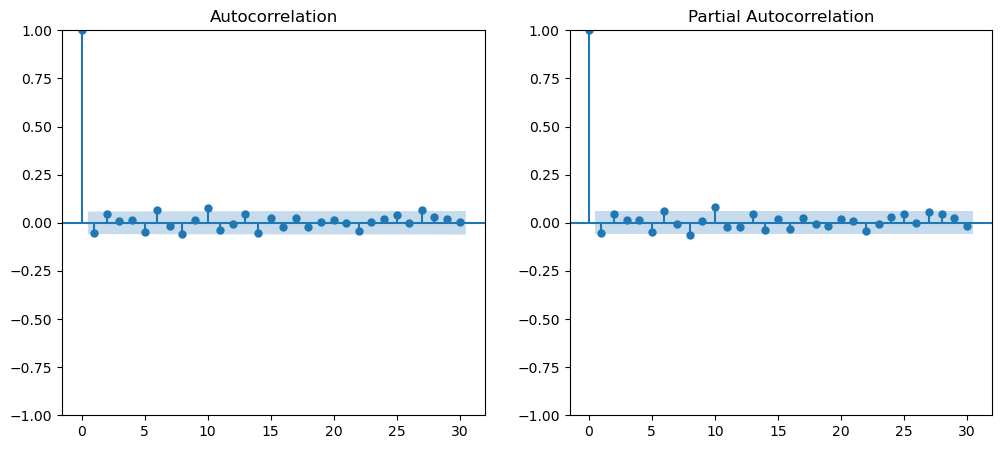

In [31]:
acf_pacf_plots(daily_returns)

The plots indicate that the rejection of the null in the Ljung-Box tests was caused by a few marginal results, namely those at lags of 1, 6, 8, and 10. Despite the rejection of nulls, the magnitude of the autocorrelation is small and there does not appear to be any clear ARMA structure or seasonality component in these results, so I move on to conduct these tests on the squared returns where I expect to see strong rejection of the null (due to volatility clustering).

In [32]:
acorr_ljungbox(daily_returns**2, lags=[7, 14, 30], return_df=True)

,lb_stat,lb_pvalue
7,117.751676,2.250762e-22
14,140.214699,6.430673e-23
30,175.657240,1.589801e-22


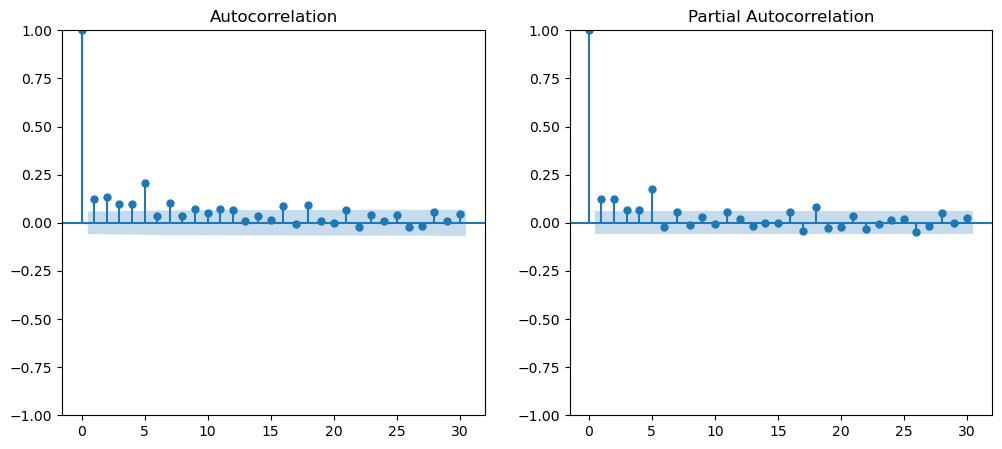

In [33]:
acf_pacf_plots(daily_returns**2)

As expected, the p-values are essentially 0 and I therefore comfortably reject the nulls at all lags tested. The plots provide further insight on the autocorrelation in squared returns, with spikes noticeably higher than those in the returns plot. Further, there appears to be a slow decay in autocorrelation as lags increase, with autocorrelations outside of the confidence bands even beyond the 14-day mark, suggesting that volatility is persistent and therefore a GARCH model is appropriate.

### Normality, skewness, and excess kurtosis

Next, I test for normality and measure skewness alongside excess kurtosis. I test for normality using the Jarque-Bera test at the 5% significance level, which is a hypothesis test with normality as the null.

In [34]:
jb_stat, jb_val = stats.jarque_bera(daily_returns)
skew = daily_returns.skew()
ex_kurt = daily_returns.kurt()

print(f"JB = {jb_stat:.1f} (p = {jb_val:.3f})")
print(f"Skewness = {skew:+.3f}")
print(f"Excess kurtosis = {ex_kurt:+.3f}")

JB = 885.9 (p = 0.000)
Skewness = -0.414
Excess kurtosis = +4.321


The Jarque-Bera test rejects normality given the extremely low p value. The skewness, while not 0, is small relative to the excess kurtosis. The excess kurtosis of ~4.3 clearly corresponds to a fat-tailed distribution, with the student's t distribution being the standard choice. I will compare the fit of the skew-t GARCH model against the t GARCH model for completeness, but I would not expect the skew to improve the model given the relative magnitudes.

In [35]:
n = len(daily_returns)
jb_skew_component = n * skew**2 / 6
jb_kurt_component = n * ex_kurt**2 / 24
print(f"JB skew part = {jb_skew_component:.1f}, kurt part  = {jb_kurt_component:.1f}")

JB skew part = 31.7, kurt part  = 864.1


I decompose the Jarque-Bera statistic into the skew component and the kurtosis component. This clearly shows that the rejection of the null is caused almost entirely by the excess kurtosis. Next, I fit the GARCH model with a student's t distribution and a skew-t distribution to compare fits.

In [36]:
fit_t = arch_model(daily_returns, vol="GARCH", p=1, q=1, dist="t", rescale=False).fit(disp="off")
fit_st = arch_model(daily_returns, vol="GARCH", p=1, q=1, dist="skewt", rescale=False).fit(disp="off")

LRatio = 2 * (fit_st.loglikelihood - fit_t.loglikelihood)
pval = 1 - stats.chi2.cdf(LRatio, df=1)

print(f"Likelihood Ratio = {LRatio:.2f}, p = {pval:.3f}")
print(f"BIC: t = {fit_t.bic:.1f}, skew-t = {fit_st.bic:.1f}")

Likelihood Ratio = 0.33, p = 0.565
BIC: t = -3831.4, skew-t = -3824.7


The likelihood ratio is not statistically significant, suggesting the skew-t MLE has converged to the symmetric model. Below, I print the fitted parameters from the skew-t model to verify this further:

In [37]:
print(fit_st.params)
print(fit_st.std_err)

mu          0.002148
omega       0.000097
alpha[1]    0.111007
beta[1]     0.853882
eta         4.730985
lambda     -0.023483
Name: params, dtype: float64
mu          0.001192
omega       0.000041
alpha[1]    0.031825
beta[1]     0.038337
eta         0.657839
lambda      0.039613
Name: std_err, dtype: float64


As expected, the lambda parameter (being that representing the skew) is small, meaning the MLE has converged to a largely symmetric model.

## Post-fit diagnostics

### Autocorrelation of residuals and goodness of fit

After fitting the symmetric t-distribution GARCH model, it is important to assess whether the model's standardised residuals behave appropriately. In particular, I need to test that the standardised residuals show no remaining autocorrelation (i.e. no uncaptured ARMA structure), the squared standardised residuals show no remaining autocorrelation (i.e. the GARCH model has captured the volatility clustering behaviour), and the standardised residuals follow a student's t distribution.

I start with a Ljung-Box test on the standardised residuals at the 5% significance level, at lags 7, 14, 30.

In [38]:
acorr_ljungbox(fit_t.std_resid, lags=[7, 14, 30], return_df=True)

,lb_stat,lb_pvalue
7,7.987731,0.333677
14,22.072614,0.077135
30,33.470226,0.302503


The results of the Ljung-Box test on the standardised residuals show no rejection of the null for all lags tested at the 5% significance level, though the p-value for the 14-day lag warrants further investigation. I plot the ACF and PACF below:

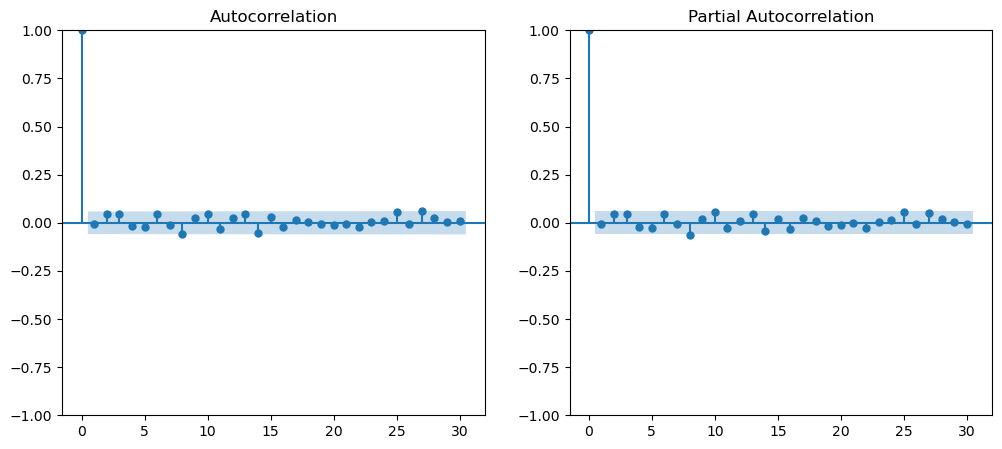

In [39]:
acf_pacf_plots(fit_t.std_resid)

Given the low magnitudes in the above plots, I am comfortable that there is no uncaptured ARMA structure, and therefore the constant mean in the fitted GARCH model appears to be sensible.

Next, I conduct another Ljung-Box test on the squared standardised residuals at the 5% significance level, again using lags of 7, 14, and 30 days. This time, "model_df" takes a value of 2 to account for the $\alpha$ and $\beta$ parameters being used in the calculation of the squared standardised residuals.

In [40]:
acorr_ljungbox(fit_t.std_resid**2, lags=[7, 14, 30], return_df=True)

,lb_stat,lb_pvalue
7,1.692538,0.974887
14,6.095550,0.964025
30,25.759375,0.687355


The Ljung-Box test on the squared standardised residuals fails to reject the null at all 3 lags tested. Therefore, the squared standardised residuals appear to follow a white noise process, and so there is no remaining volatility clustering to be captured. I verify this further by plotting the ACF and PACF below.

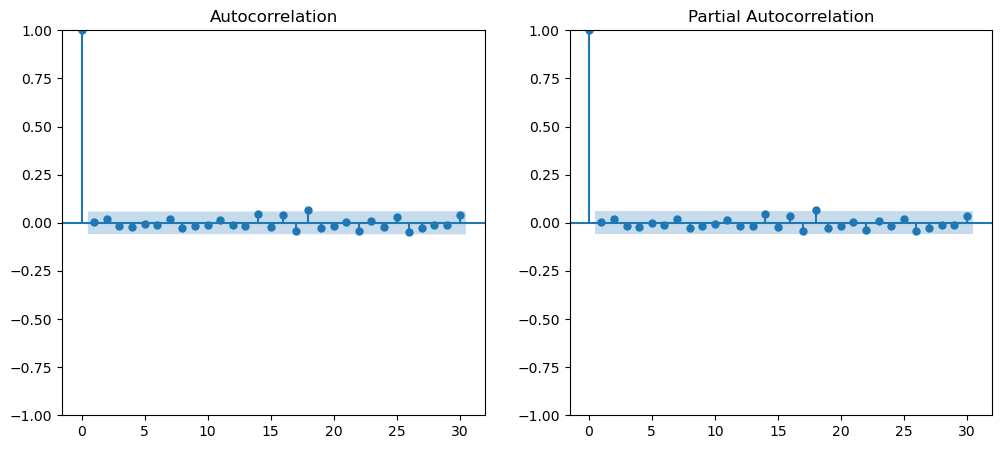

In [41]:
acf_pacf_plots(fit_t.std_resid**2)

Consistent with the Ljung-Box test, there do not appear to be any lags with statistically significant autocorrelations. The closest seems to be the 18-day lag, but given the results of the Ljung-Box test I am happy to conclude that the volatility clustering behaviour has been captured.

Next, I visually assess whether the standardised residuals of the fitted GARCH model follow the student's t distribution via a QQ plot. The QQ plot shows the theoretical quantiles of a student's t distribution with the fitted degrees of freedom against the standardised residuals of the model. The closer the points follow the line, the better the fit of the model.

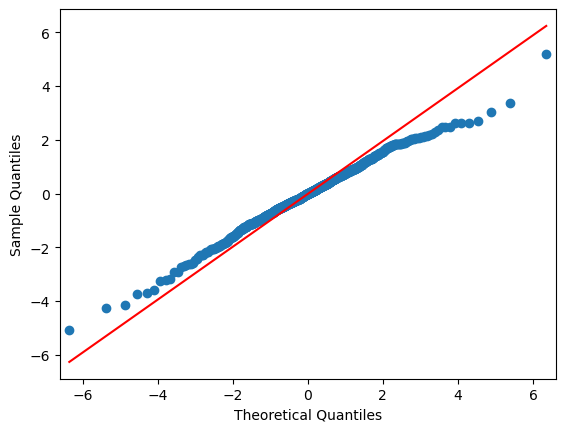

In [42]:
sm.qqplot(fit_t.std_resid, dist=stats.t, distargs=(fit_t.params["nu"],), line="s")
plt.show()

The sample quantiles broadly follow the theoretical quantiles, with some deviation at the tails, somewhat larger for the upper tail. Despite these characteristics, the tests conducted earlier to assess skew give me confidence that a skewed distribution would not provide a better fit, and so I am satisfied with the fit of the GARCH model with a symmetric student's t distribution.

## Rolling window fit

Given the above pre and post-fit diagnostic results, I will use a GARCH(1,1) model with a symmetric student's t distribution for the rolling forecasts. Here, I depart from Chi and Hao's methodology by using a fixed-length rolling window rather than an expanding window. A fixed window maintains a constant estimation window size, ensuring comparability across time and dropping older stale observations. In a future analysis I may conduct a sensitivity test to compare results under an expanding window.

In [43]:
rolling_returns = daily_klines_df["return"][:options_df["timestamp"].max()]

In [44]:
# Identify options date range
time_range = options_df["timestamp"].max() - options_df["timestamp"].min() + pd.Timedelta(days=1)

pos = rolling_returns.index.get_loc(options_df["timestamp"].min() + pd.Timedelta(days=1))

forecasts = {}
results = {}

# I ran into issues with the in-built rescale parameter, so I instead manually scale returns by a factor of 100.
model = arch_model(rolling_returns * 100, vol="Garch", p=1, q=1, dist="t", rescale=False)

for i in range(time_range.days):
    sys.stdout.write(".")
    sys.stdout.flush()
    
    # This try-except clause ensures that all windows are calculated, even if some parameters do not converge under the MLE.
    try:
        res=model.fit(first_obs=i, last_obs=pos+i, disp="off")
    except:
        print("\nError occurred:")
        print(rolling_returns.index[pos+i])
        continue
    forecast = res.forecast(horizon=1, reindex=False).variance.iloc[0]
    forecasts[forecast.name] = forecast
    
    # Save alpha and beta parameters alongside standard errors and p-values.
    results[forecast.name] = {
        "alpha": res.params["alpha[1]"],
        "beta": res.params["beta[1]"],
        "alpha_se": res.std_err["alpha[1]"],
        "beta_se": res.std_err["beta[1]"],
        "alpha_pval": res.pvalues["alpha[1]"],
        "beta_pval": res.pvalues["beta[1]"]
    }
    
    
print()
print(pd.DataFrame(forecasts).T)

...............................................................................................................................................................
                                h.1
2023-05-18 00:00:00+00:00  8.574686
2023-05-19 00:00:00+00:00  8.155707
2023-05-20 00:00:00+00:00  7.763134
2023-05-21 00:00:00+00:00  7.536625
2023-05-22 00:00:00+00:00  7.180516
...                             ...
2023-10-19 00:00:00+00:00  3.869266
2023-10-20 00:00:00+00:00  4.103156
2023-10-21 00:00:00+00:00  4.020527
2023-10-22 00:00:00+00:00  4.127612
2023-10-23 00:00:00+00:00  7.158877

[159 rows x 1 columns]


Next, I plot the alpha and beta parameters from each of the GARCH windows to assess stability over time.

In [45]:
alpha_beta = pd.DataFrame(results).T
alpha_beta["sum"] = alpha_beta["alpha"] + alpha_beta["beta"]

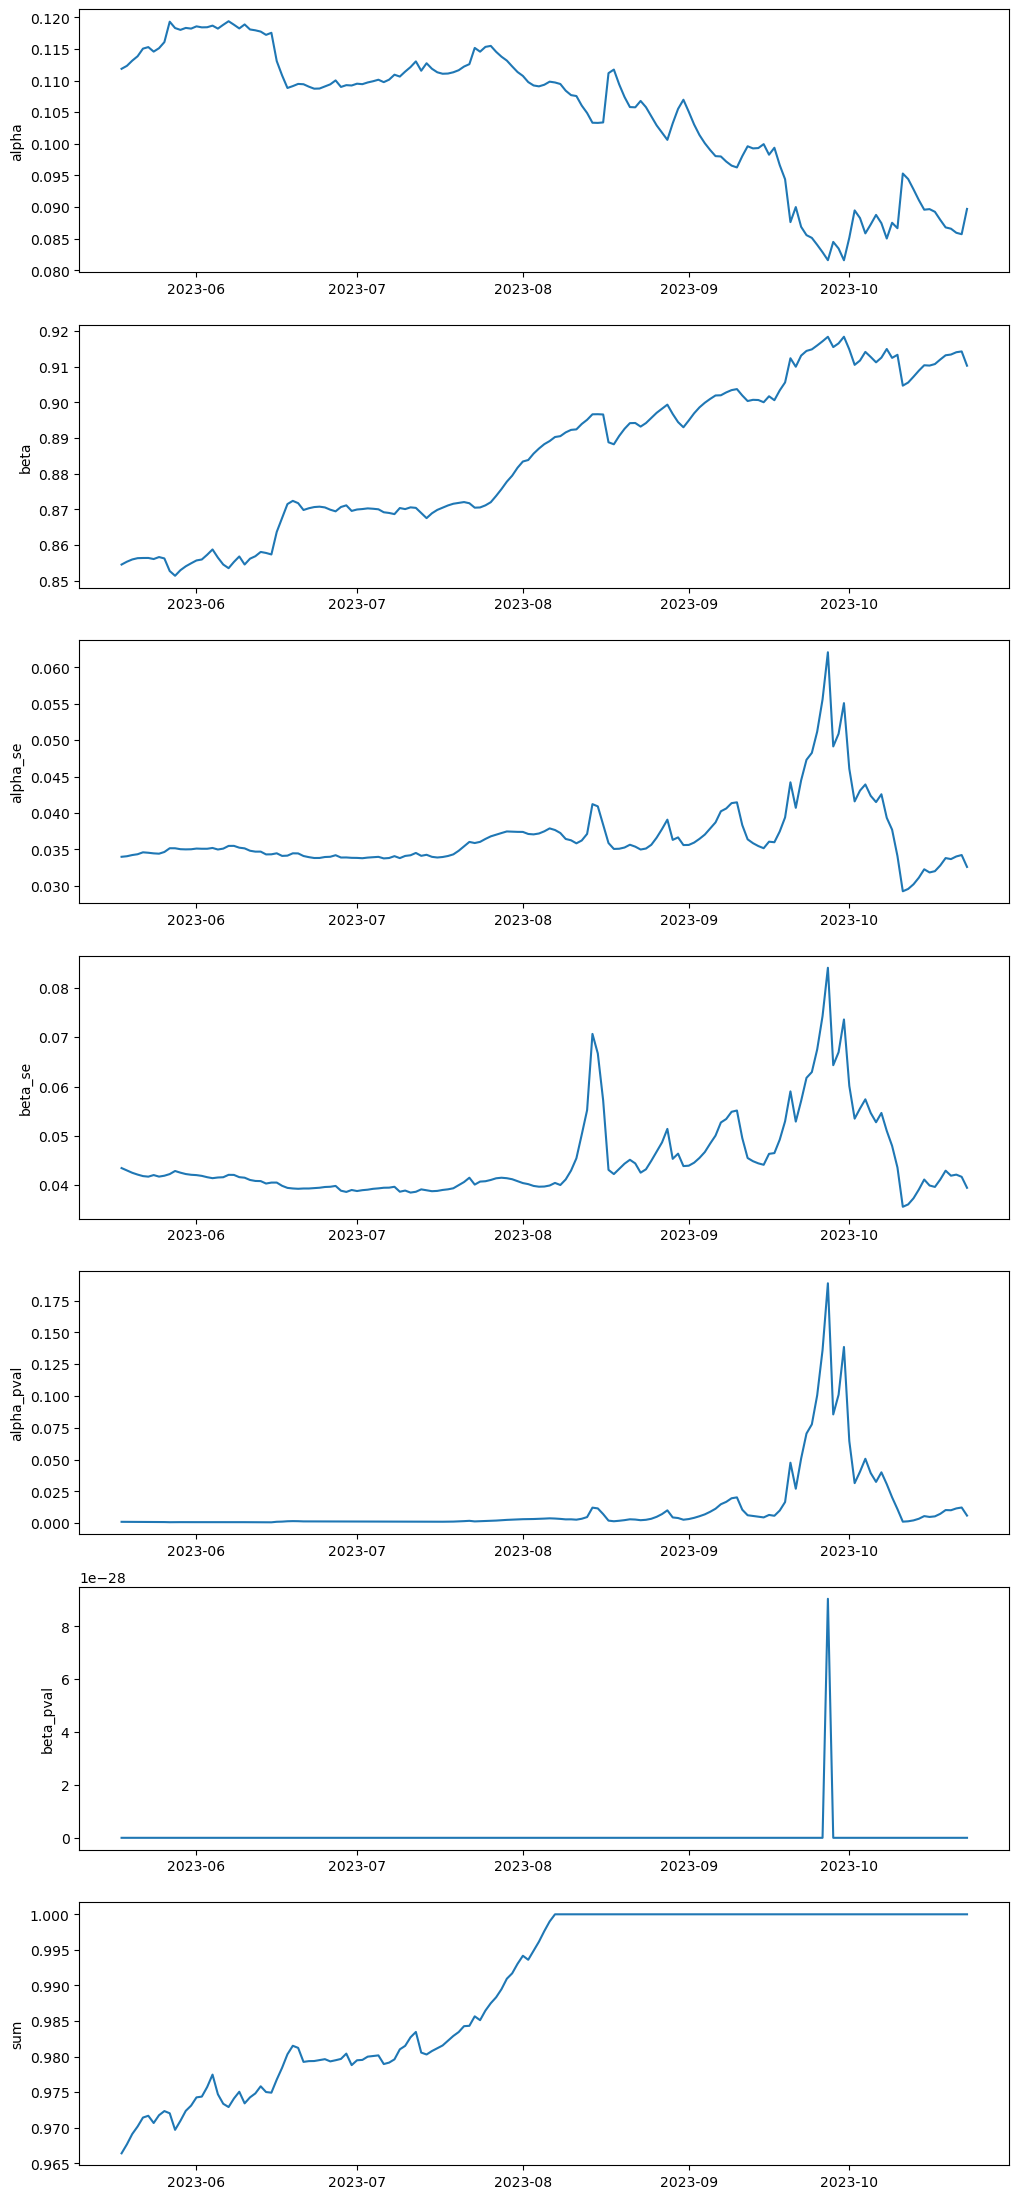

In [46]:
fig, axes = plt.subplots(nrows=len(alpha_beta.columns), ncols=1, figsize=(12,4*len(alpha_beta.columns)))

for i, param in enumerate(alpha_beta.columns):
    sns.lineplot(data=alpha_beta[param], ax=axes[i])

plt.show()

In [47]:
print(f"Max alpha p-value: {alpha_beta["alpha_pval"].max():.2f}")

Max alpha p-value: 0.19


In [48]:
first_1_date = alpha_beta["sum"][alpha_beta["sum"] >= 1].index.min()
dropped_date = first_1_date - pd.Timedelta(days=1111)
print(f"First date at which alpha + beta = 1 is {first_1_date.strftime('%d %B %Y')}. \nThe date which had just been dropped from the GARCH window is {dropped_date.strftime('%d %B %Y')}.")

First date at which alpha + beta = 1 is 07 August 2023. 
The date which had just been dropped from the GARCH window is 22 July 2020.


The sum of parameters is relatively stable but drifts upwards, reaching a point where $\alpha + \beta = 1$ on 7 August 2023 and remaining there from that point onwards, with $\beta$ increasing and $\alpha$ decreasing through the entire period. 

The standard error plots spike around mid August, shortly after the point at which $\alpha + \beta = 1$, before quickly returning to their pre-spike levels, with a much larger spike for $\beta$ than for $\alpha$. They then increase significantly from mid September to early October, before once again returning to their pre-spike levels. The combined effect of $\alpha$ decreasing and its standard errors spiking around mid September results in a spike in its p-value, increasing to around 0.19 and remaining above the 5% threshold until the start of October.

A GARCH model where $\alpha + \beta = 1$ is known as IGARCH (Integrated GARCH), which means that the GARCH process is non-stationary, i.e. shocks to the system do not decay over time. To investigate why $\alpha + \beta$ converges to 1, I look at returns that are dropped from the estimation window around when $\alpha + \beta$ first equals 1.

In [49]:
daily_returns[dropped_date:dropped_date + pd.Timedelta(days=14)]

open_time
2020-07-22 00:00:00+00:00    0.071300
2020-07-23 00:00:00+00:00    0.042898
2020-07-24 00:00:00+00:00    0.013888
2020-07-25 00:00:00+00:00    0.089415
2020-07-26 00:00:00+00:00    0.018629
2020-07-27 00:00:00+00:00    0.034541
2020-07-28 00:00:00+00:00   -0.016158
2020-07-29 00:00:00+00:00    0.002963
2020-07-30 00:00:00+00:00    0.052603
2020-07-31 00:00:00+00:00    0.033650
2020-08-01 00:00:00+00:00    0.111033
2020-08-02 00:00:00+00:00   -0.038402
2020-08-03 00:00:00+00:00    0.035660
2020-08-04 00:00:00+00:00    0.009464
2020-08-05 00:00:00+00:00    0.028117
Freq: D, Name: return, dtype: float64

<Axes: title={'center': 'Realised volatility'}, xlabel='open_time'>

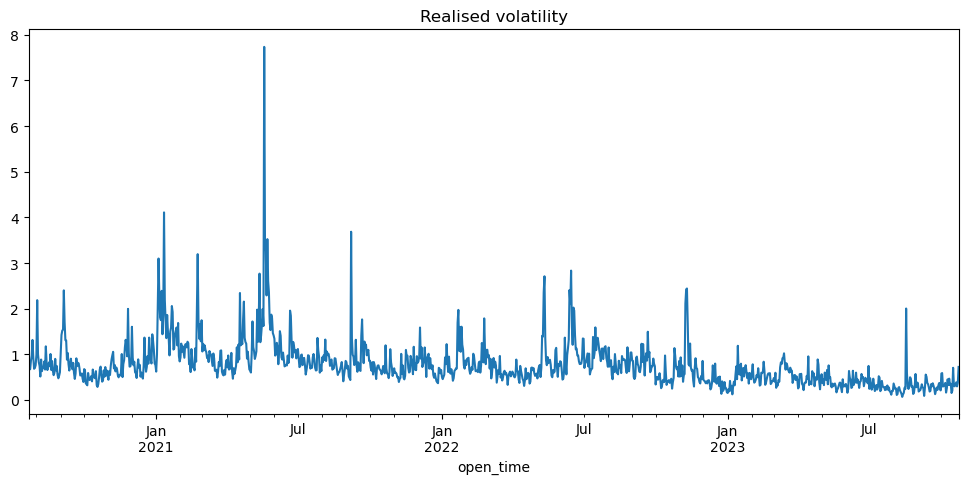

In [50]:
realised_vol_1d_annual[dropped_date:options_df["timestamp"].max()].plot(title="Realised volatility", figsize=(12,5))

While the point at which $\alpha + \beta = 1$ coincides with a period of very high log returns being dropped from the estimation window (~7%, ~9%, ~11% all within a 14-day period, with only 2 of the 14 days experiencing returns with a magnitude less than 1%), the realised volatility plot above demonstrates that this period is far from the most volatile in the dataset. It is therefore not clear to me why persistence ($\alpha + \beta$) drifts up to 1, and identifying the cause may be a useful direction for future analyses. It is similarly not clear what drives the spikes in standard errors for both parameters or the p-value for $\alpha$.

In [51]:
# I convert the forecasts into a dataframe
forecasts_df = pd.DataFrame(forecasts).T

# The 1-day volatility forecast needs to be divided by 100 to adjust for the multiplication in the model fitting
forecasts_df["1day_vol_forecast"] = np.sqrt(forecasts_df.sum(axis=1))  / 100

# Multiplying by the square root of 365 adjusts the 1-day forecast to an annnualised figure
forecasts_df["1day_vol_forecast_annualised"] = forecasts_df["1day_vol_forecast"] * np.sqrt(365)
forecasts_df.head()

,h.1,1day_vol_forecast,1day_vol_forecast_annualised
2023-05-18 00:00:00+00:00,8.574686,0.029283,0.559443
2023-05-19 00:00:00+00:00,8.155707,0.028558,0.545604
2023-05-20 00:00:00+00:00,7.763134,0.027862,0.532310
2023-05-21 00:00:00+00:00,7.536625,0.027453,0.524487
2023-05-22 00:00:00+00:00,7.180516,0.026796,0.511946


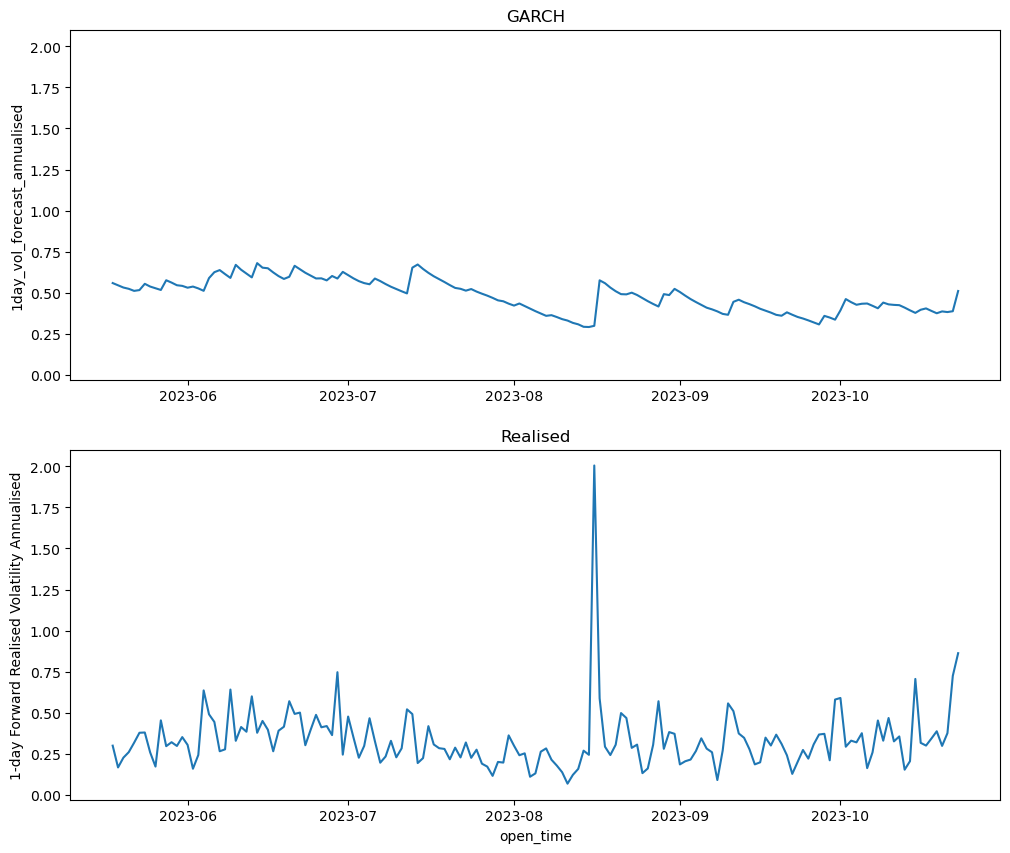

In [52]:
# I plot forward realised volatility vs GARCH forecasted volatility
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12,10), sharey=True)

sns.lineplot(data=forecasts_df["1day_vol_forecast_annualised"], ax=axes[0])

sns.lineplot(data=fwd_realised_vol_1d_annual[forecasts_df.index[0]:forecasts_df.index[-1]], ax=axes[1])

axes[0].set_title("GARCH")

axes[1].set_title("Realised")

plt.show()

In [53]:
forecast_window_realised = fwd_realised_vol_1d_annual[pd.date_range(start=forecasts_df.index[0], end=forecasts_df.index[-1], freq="D")]

realised_diff = forecast_window_realised - forecast_window_realised.shift(1)
max_val_realised = realised_diff.max()
min_val_realised = realised_diff.min()

vol_spike = realised_diff[realised_diff == max_val_realised].index[0]
vol_crash = realised_diff[realised_diff == min_val_realised].index[0]

print(f"Date of forward vol spike: {vol_spike.strftime('%d %B %Y')}.")
print(f"Date of forward vol crash: {vol_crash.strftime('%d %B %Y')}.")

Date of forward vol spike: 16 August 2023.
Date of forward vol crash: 17 August 2023.


In [54]:
GARCH_diff = forecasts_df["1day_vol_forecast_annualised"] - forecasts_df["1day_vol_forecast_annualised"].shift(1)
max_val_GARCH = GARCH_diff.max()

print(f"Max realised volatility difference: {max_val_realised:.2f}.")
print(f"Max GARCH forecast volatility difference: {max_val_GARCH:.2f}.")

Max realised volatility difference: 1.76.
Max GARCH forecast volatility difference: 0.28.


In [55]:
# Given that the GARCH forecasts react to spikes in realised vol rather than forward realised vol, I adjust the calculation period by 1 day.
pre_spike_mean_realised = forecast_window_realised[:vol_spike-pd.Timedelta(days=1)].mean()
pre_spike_mean_GARCH = forecasts_df["1day_vol_forecast_annualised"][:vol_spike].mean()

post_crash_mean_realised = forecast_window_realised[vol_crash:].mean()
post_crash_mean_GARCH = forecasts_df["1day_vol_forecast_annualised"][vol_crash+pd.Timedelta(days=1):].mean()

print(f"Pre-spike mean forward realised annualised volatility: {pre_spike_mean_realised:.2f}.")
print(f"Pre-spike mean forecast annualised volatility: {pre_spike_mean_GARCH:.2f}.")
print(f"Post-crash mean forward realised annualised volatility: {post_crash_mean_realised:.2f}.")
print(f"Post-crash mean forecast annualised volatility: {post_crash_mean_GARCH:.2f}.")

Pre-spike mean forward realised annualised volatility: 0.32.
Pre-spike mean forecast annualised volatility: 0.53.
Post-crash mean forward realised annualised volatility: 0.34.
Post-crash mean forecast annualised volatility: 0.42.


The above plot of GARCH 1-day volatility forecasts against forward realised 1-day volatility demonstrates a consistent overestimate by the GARCH model prior to the spike on 16 August 2023 (realised average: 0.32; forecast average: 0.53).

During the August volatility spike, the GARCH forecasts can also be seen to spike, but at a much smaller magnitude than the realised volatility (differenced figures being 1.76 vs 0.28). This is to be expected, given the structural inability of GARCH to quickly capture extreme volatility spikes. 

After realised volatility crashes back down to the pre-spike level on 17 August 2023, the GARCH forecasts still overestimate volatility, but to a lesser extent (realised average: 0.34; forecast average: 0.42).

In [56]:
print(f"Maxlags calculation = {4*(159/100)**(2/9):.2f}")

Maxlags calculation = 4.43


I formally test the forecast accuracy using a Mincer-Zarnowitz regression and a Wald test. A Mincer-Zarnowitz regression is the standard for evaluating whether forecasts are unbiased and efficient. In this case it takes the form:
$$
RV_t = \alpha + \beta \cdot \hat{\sigma}_t + \varepsilon_t
$$
Where $RV_t$ is the forward realised volatility at time $t$ and $\hat{\sigma}_t$ is the GARCH volatility forecast at time $t$.

A perfect forecast would have an $\alpha$ coefficient of 0, and a $\beta$ coefficient of 1. Any non-zero value of $\alpha$ means the forecast is systematically either too high or too low (depending on the sign), while a value of $\beta$ being different to 1 means the forecast either moves too much or too little as the realised volatility moves.

The Wald test is a joint hypothesis test where the null is that $\alpha$ is 0 ***and*** $\beta$ is 1, which I conduct at the 5% significance level.

Given the clustering nature of volatility, I use Heteroskedasticity and Autocorrelation Consistent (HAC) standard errors (a.k.a. Newey-West standard errors) in the Mincer-Zarnowitz regression. The choice of lags I derive from the Newey-West (1994)<sup>[4]</sup> rule of thumb, being $4 \cdot (T/100)^{(2/9)}$, which in this case with T = 159 gives ~4.

---
<sup>[4]</sup> Newey, W. K., & West, K. D. (1994). Automatic lag selection in covariance matrix estimation. *The Review of Economic Studies, 61*(4), 631-653.

In [57]:
rv = forecast_window_realised
fv = forecasts_df["1day_vol_forecast_annualised"]

X = sm.add_constant(fv)
y = rv

model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags":4})

print(model.summary())
print(model.wald_test("const = 0, 1day_vol_forecast_annualised = 1", use_f=False, scalar=False))

                                         OLS Regression Results                                         
Dep. Variable:     1-day Forward Realised Volatility Annualised   R-squared:                       0.004
Model:                                                      OLS   Adj. R-squared:                 -0.002
Method:                                           Least Squares   F-statistic:                    0.3361
Date:                                          Fri, 12 Jun 2026   Prob (F-statistic):              0.563
Time:                                                  15:53:31   Log-Likelihood:                 38.461
No. Observations:                                           159   AIC:                            -72.92
Df Residuals:                                               157   BIC:                            -66.78
Df Model:                                                     1                                         
Covariance Type:                                       

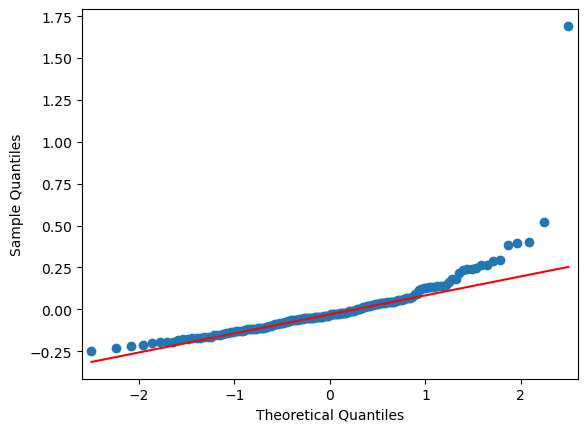

In [58]:
sm.qqplot(model.resid, line="q")
plt.show()

The earlier QQ-plots used a line parameter value of "s", which plots theoretical quantiles based on the series' mean and standard deviation, but here I have an extreme outlier in the 16 August volatility spike, which would bias the theoretical quantiles. Therefore, I use a line parameter value of "q" in the QQ-plot such that the theoretical quantiles are plotted based on the 1st and 3rd quartiles. The plot shows points largely hugging the theoretical quantile line due to forward realised volatility being relatively flat over this forecasting period, with the forward volatility spike on 16 Aug being clearly visible as the right-most point. The deviation at the right tail is further validation for the use of HAC errors, alongside the Durbin-Watson value of 1.5.

Looking at the parameter estimates, the coefficient for "1day_vol_forecast_annualised" ($\beta$) is 0.13, but is not statistically significant. The coefficient for "const" ($\alpha$) is consistent with the systematic overestimate of the GARCH forecasts noted earlier when comparing pre-crash and post-crash mean volatility, which is statistically significant at the 5% significance level and takes a value of 0.27. The model's adjusted $R^2$ of ~0 indicates that the GARCH forecasts explain close to none of the forward realised volatility.

The Wald test strongly rejects the null of $\alpha = 0$ and $\beta = 1$, with a p-value of essentially 0 which is driven both by the statistically significant value for $\alpha$ of 0.27 and the statistically insignificant (i.e. indistinguishable from 0) value for $\beta$ of 0.13, which is far from 1.

## 365-day Rolling GARCH Model

One hypothesis for the low explanatory power of the GARCH forecasts is due to the forecasting range being particularly calm relative to the estimation window. Therefore, as a sensitivity check I test whether expanding the forecast range to 365 days, including the volatile period in November 2022, improves the MZ regression results.

<Axes: xlabel='open_time'>

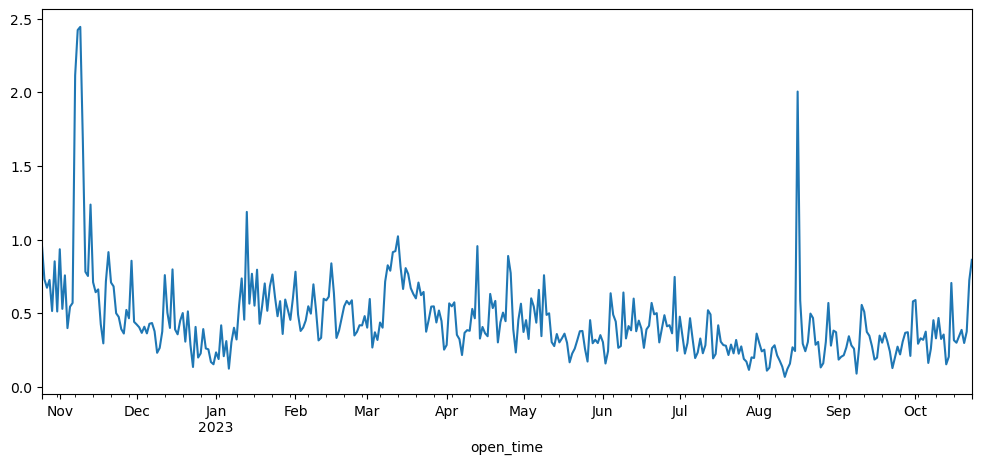

In [59]:
fwd_realised_vol_1d_annual[options_df["timestamp"].max() + pd.Timedelta(hours=1) - pd.Timedelta(days=364):options_df["timestamp"].max()].plot(figsize=(12,5))

In [60]:
time_range = pd.Timedelta(days=365)

pos_365 = rolling_returns.index.get_loc(options_df["timestamp"].max() + pd.Timedelta(hours=1) - pd.Timedelta(days=364))

forecasts_365 = {}
results_365 = {}

# I ran into issues with the in-built rescale parameter, so I instead manually scale returns by a factor of 100.
model = arch_model(rolling_returns * 100, vol="Garch", p=1, q=1, dist="t", rescale=False)

for i in range(time_range.days):
    sys.stdout.write(".")
    sys.stdout.flush()
    
    # This try-except clause ensures that all windows are calculated, even if some parameters do not converge under the MLE.
    try:
        res=model.fit(first_obs=i, last_obs=pos_365+i, disp="off")
    except:
        print("\nError occurred:")
        print(rolling_returns.index[pos_365+i])
        continue
    forecast = res.forecast(horizon=1, reindex=False).variance.iloc[0]
    forecasts_365[forecast.name] = forecast
    
    # Save alpha and beta parameters alongside standard errors and p-values.
    results_365[forecast.name] = {
        "alpha": res.params["alpha[1]"],
        "beta": res.params["beta[1]"],
        "alpha_se": res.std_err["alpha[1]"],
        "beta_se": res.std_err["beta[1]"],
        "alpha_pval": res.pvalues["alpha[1]"],
        "beta_pval": res.pvalues["beta[1]"]
    }
    
    
print()
print(pd.DataFrame(forecasts_365).T)

.............................................................................................................................................................................................................................................................................................................................................................................
                                 h.1
2022-10-24 00:00:00+00:00  11.472803
2022-10-25 00:00:00+00:00  17.436695
2022-10-26 00:00:00+00:00  20.746929
2022-10-27 00:00:00+00:00  20.329178
2022-10-28 00:00:00+00:00  19.156596
...                              ...
2023-10-19 00:00:00+00:00   2.928915
2023-10-20 00:00:00+00:00   3.287076
2023-10-21 00:00:00+00:00   3.322938
2023-10-22 00:00:00+00:00   3.537375
2023-10-23 00:00:00+00:00   5.968621

[365 rows x 1 columns]


In [61]:
alpha_beta_365 = pd.DataFrame(results_365).T
alpha_beta_365["sum"] = alpha_beta_365["alpha"] + alpha_beta_365["beta"]

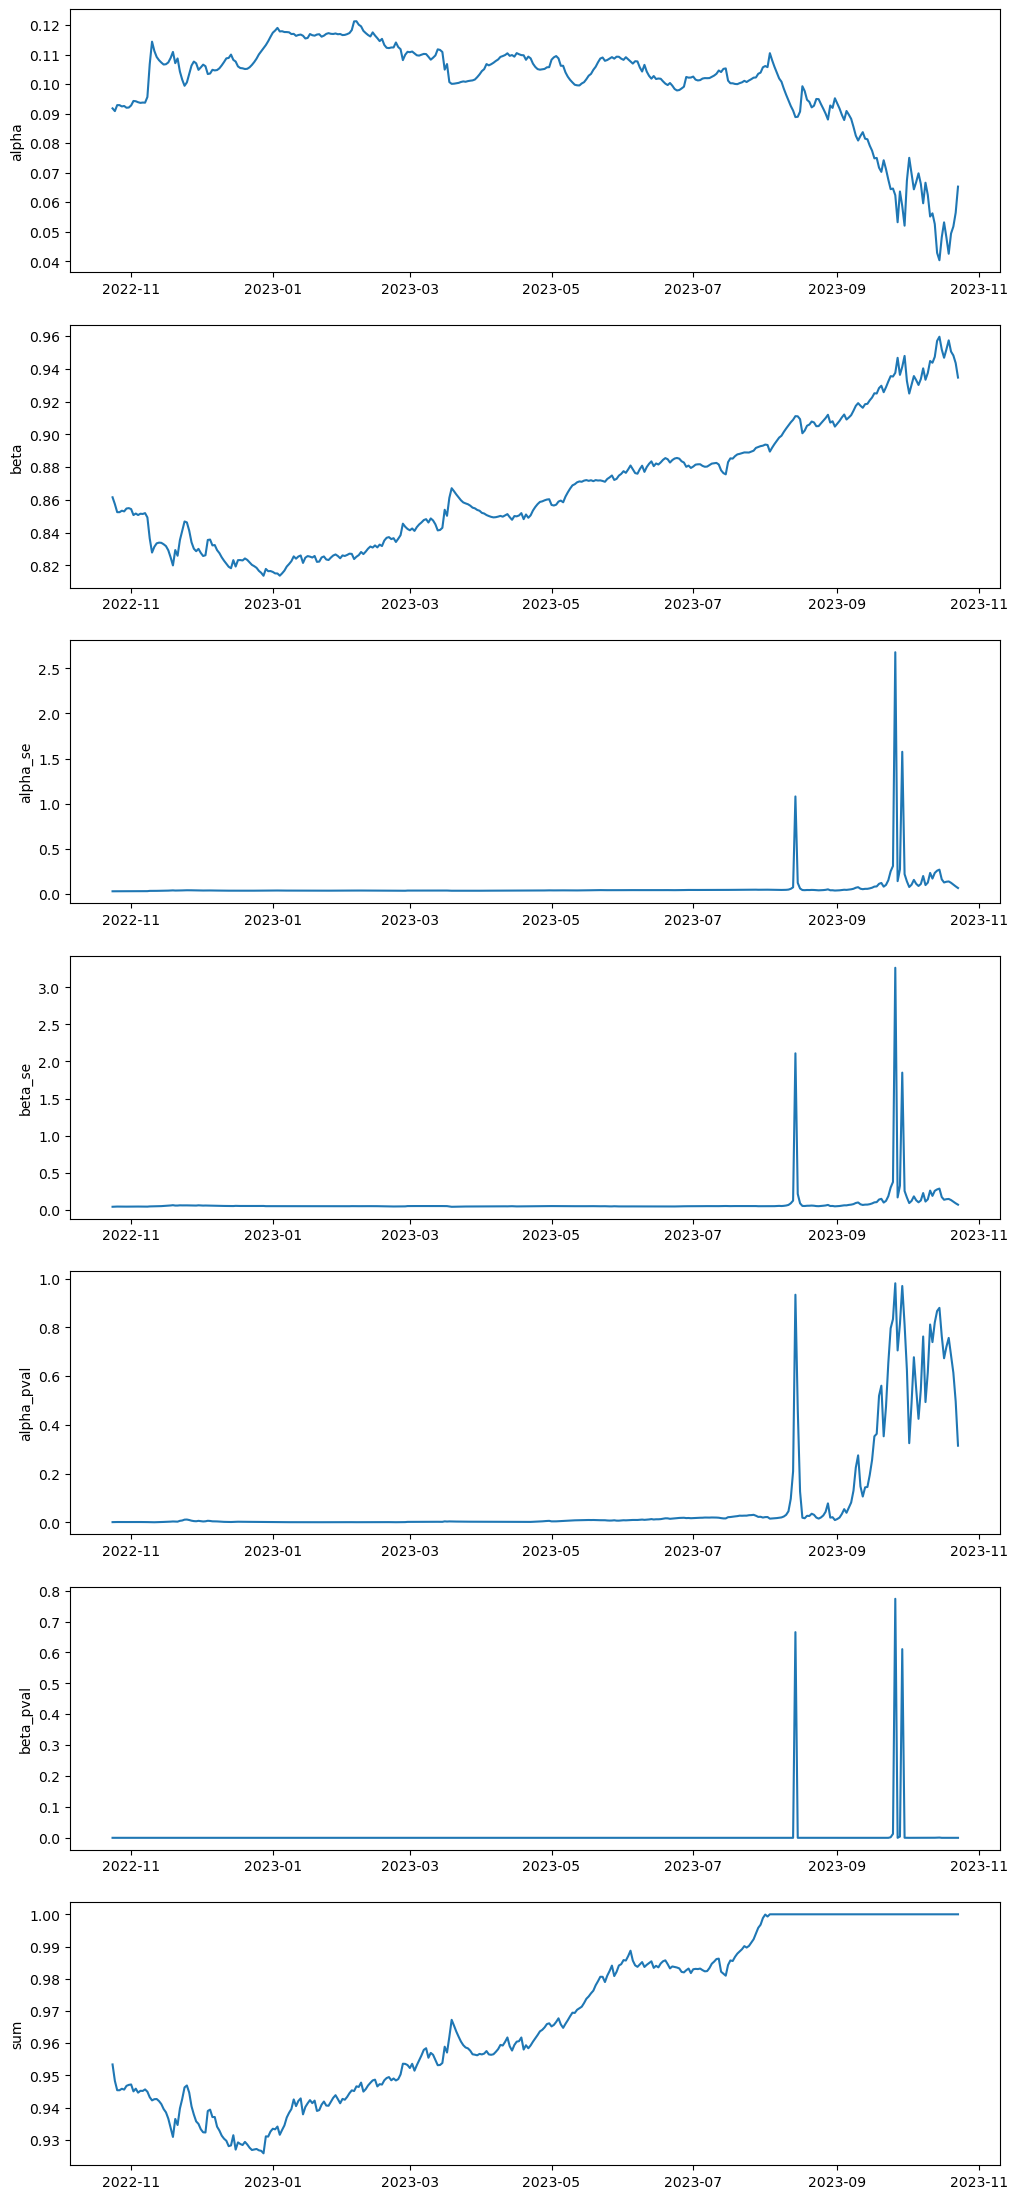

In [62]:
fig, axes = plt.subplots(nrows=len(alpha_beta_365.columns), ncols=1, figsize=(12,4*len(alpha_beta_365.columns)))

for i, param in enumerate(alpha_beta_365.columns):
    sns.lineplot(data=alpha_beta_365[param], ax=axes[i])

plt.show()

As with the earlier plots, the sum of $\alpha$ and $\beta$ drifts up to 1 around August 2023, with corresponding spikes in the standard errors for both parameters. The p-value for $\alpha$ similarly spikes again, though this time there is also a spike in the p-value for $\beta$. It is still not clear to me what is driving this behaviour.

In [63]:
# I convert the forecasts into a dataframe
forecasts_365_df = pd.DataFrame(forecasts_365).T

# The volatility forecast needs to be divided by 100 to adjust for the multiplication in the model fitting
forecasts_365_df["365_vol_forecast"] = np.sqrt(forecasts_365_df.sum(axis=1))  / 100

# Multiplying by the square root of 365 adjusts the forecast to an annnualised figure
forecasts_365_df["365_vol_forecast_annualised"] = forecasts_365_df["365_vol_forecast"] * np.sqrt(365)
forecasts_365_df.head()

,h.1,365_vol_forecast,365_vol_forecast_annualised
2022-10-24 00:00:00+00:00,11.472803,0.033872,0.647115
2022-10-25 00:00:00+00:00,17.436695,0.041757,0.797771
2022-10-26 00:00:00+00:00,20.746929,0.045549,0.870209
2022-10-27 00:00:00+00:00,20.329178,0.045088,0.861403
2022-10-28 00:00:00+00:00,19.156596,0.043768,0.836191


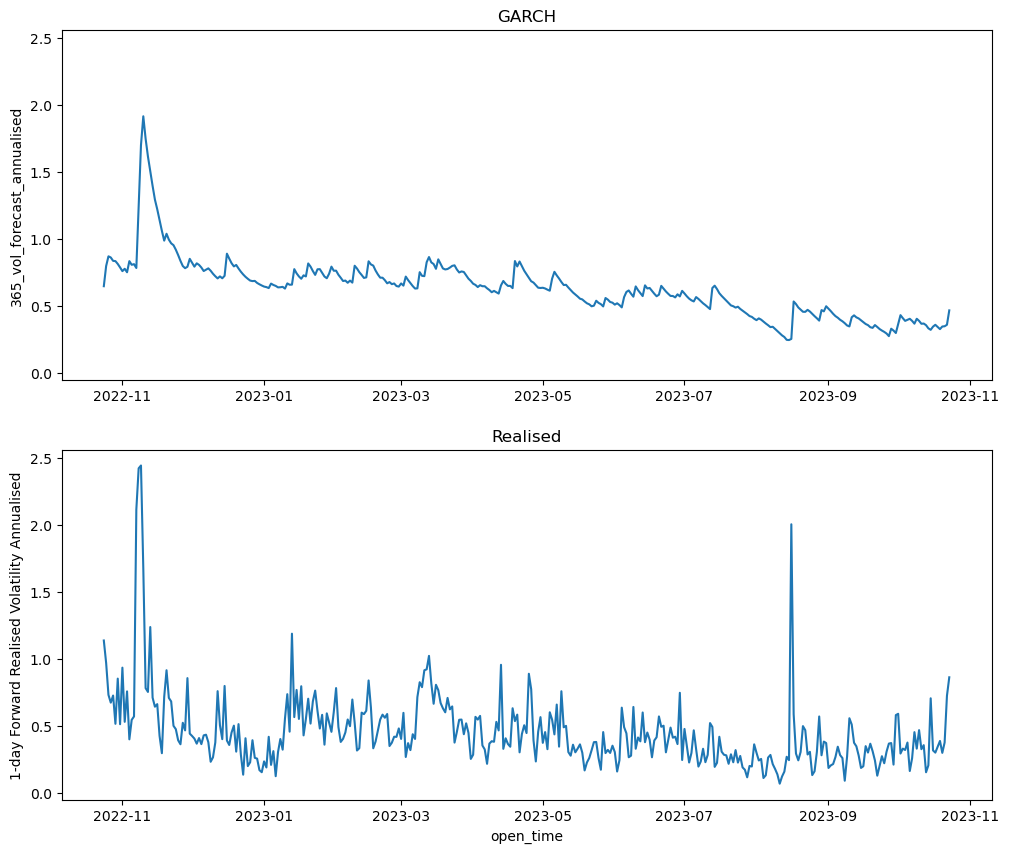

In [64]:
# I plot realised volatility vs GARCH forecasted volatility
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12,10), sharey=True)

sns.lineplot(data=forecasts_365_df["365_vol_forecast_annualised"], ax=axes[0])

sns.lineplot(data=fwd_realised_vol_1d_annual[forecasts_365_df.index[0]:forecasts_365_df.index[-1]], ax=axes[1])

axes[0].set_title("GARCH")

axes[1].set_title("Realised")

plt.show()

This plot shows a similar pattern to the earlier plot, but this time there is a clear spike in the GARCH forecast plot in November 2022, around the same time as the spike in forward realised volatility.

In [65]:
forecast_window_realised_365 = fwd_realised_vol_1d_annual[pd.date_range(start=forecasts_365_df.index[0], end=forecasts_365_df.index[-1], freq="D")]
print(f"Maxlags calculation = {4*(365/100)**(2/9):.2f}")

Maxlags calculation = 5.33


I run another Mincer-Zarnowitz regression and Wald test using the new series. This time there are 365 observations, so I use a "maxlags" parameter of 5 based on the same rule of thumb.

In [66]:
rv_365 = forecast_window_realised_365
fv_365 = forecasts_365_df["365_vol_forecast_annualised"]

X = sm.add_constant(fv_365)
y = rv_365

model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags":5})

print(model.summary())
print(model.wald_test("const = 0, 365_vol_forecast_annualised = 1", use_f=False, scalar=False))

                                         OLS Regression Results                                         
Dep. Variable:     1-day Forward Realised Volatility Annualised   R-squared:                       0.293
Model:                                                      OLS   Adj. R-squared:                  0.291
Method:                                           Least Squares   F-statistic:                     21.88
Date:                                          Fri, 12 Jun 2026   Prob (F-statistic):           4.11e-06
Time:                                                  15:53:34   Log-Likelihood:                 6.9125
No. Observations:                                           365   AIC:                            -9.825
Df Residuals:                                               363   BIC:                            -2.025
Df Model:                                                     1                                         
Covariance Type:                                       

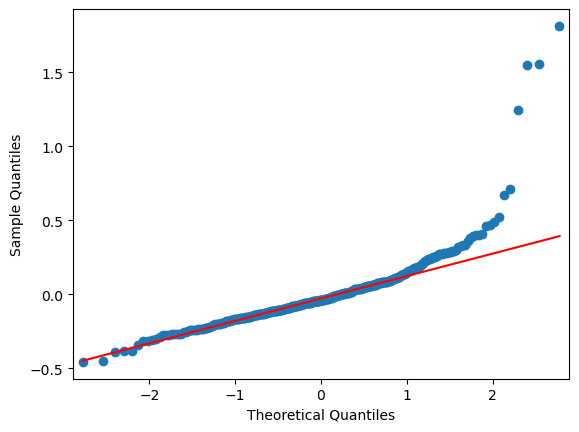

In [67]:
sm.qqplot(model.resid, line="q")
plt.show()

In [68]:
print(f"Earlier window size: {pos}.")
print(f"Current window size: {pos_365}.")

Earlier window size: 1112.
Current window size: 906.


The contrast in results is large, but the Wald test still rejects the joint null that $\alpha = 0$ and $\beta = 1$. This time the adjusted $R^2$ is 0.291 instead of ~0, with a statistically significant coefficient of 0.69 for the GARCH forecasts. This means that any unit increase in GARCH forecast corresponds with a 0.69 increase in forward realised volatility, i.e. the GARCH forecasts overestimate forward realised volatility.

The QQ-plot shows a clear deviation at the right tail, consistent with the skew and kurtosis reported in the Mincer-Zarnowitz regression results, this time with several extreme outliers rather than just the single August volatility spike.

One caveat to this comparison is that the estimation windows for the GARCH forecasts are not aligned: the earlier rolling window was 1112 days long, whereas this rolling window is 906 days long. This is due to using all data from the beginning of the dataset in both instances, but the second analysis using an earlier forecasting window. I do not expect a significant change in results to arise from acquiring more data to ensure estimations windows are of consistent size, but that is a sensitivity check I will perform in future analyses.

# IV Analysis

I now look at implied volatility (IV) from the options dataset (options_df), which contains end-of-hour summaries of options data for ETH/USDT over a ~5 month period from 18 May 2023 to 23 October 2023. The goal of this section is to compare the ability of IV to forecast forward realised volatility with that of the GARCH forecasts. Given the results of the GARCH analysis over the smaller forecasting window, I would expect IV to outperform.
 
I use the measure of IV provided by Binance, "mark_iv", in the options data for simplicity, though fitting a volatility surface from the underlying options contracts is a possible direction for future analysis. "mark_iv" is presented as an annualised figure which is representative of the risk-neutral expected volatility over the lifetime of the contract (which may include a volatility risk premium<sup>[5]</sup>). 

Consistent with Chi and Hao (2021), I identify a frequently-traded, long-dated options contract expiring after my forecast window and track its IV daily to create a series for IV. Note that this construction means the comparison is between a 1-day forecast (GARCH) and a longer-horizon forecast (IV) which only partially responds to changes in short-term volatility expectations, the implications of which I return to when interpreting the results. I also restrict observations to those with a 'moneyness' between 0.95 and 1.05, calculated as the strike price of the option divided by the underlying spot price, to isolate roughly ATM options such that their IVs are minimally distorted by the volatility smile.

---
<sup>[5]</sup> A volatility risk premium is where an option's IV is systematically higher than the forward realised volatility, compensating options sellers at a greater level than the realised volatility would justify.

In [69]:
# I merge the underlying spot price from "klines_df" to "options_df", then calculate moneyness.
options_df = pd.merge(options_df, klines_df.loc[:,"close"].rename("close_underlying"), how="left", left_on="timestamp", right_index=True)
options_df["moneyness"] = options_df["strike"]/options_df["close_underlying"]

In [70]:
# I identify options contracts with expiries after the end of the forecasting period
options_df["expiry"].dt.date.value_counts().sort_index()[options_df["timestamp"].max().date():]

expiry
2023-10-27     59648
2023-11-03      7542
2023-11-24     30860
2023-12-29    133034
2024-03-29    118988
2024-06-28     61030
2024-09-27      7040
Name: count, dtype: int64

In [71]:
# I test how many unique dates the 29 Dec 2023 option is traded on, given it has the greatest number of unique entries 
dec_contract = options_df[options_df["expiry"].dt.date == pd.to_datetime("2023-12-29").date()]
dec_contract["timestamp"].dt.date.nunique()

147

This count of 147 dates is exactly what would be expected, given the 159 possible dates with 12 missing due to data unavailability.

In [72]:
# I filter for moneyness between 0.95 and 1.05 and print description statistics
dec_atm = dec_contract[dec_contract["moneyness"].between(0.95, 1.05)]
dec_atm.groupby(dec_atm["timestamp"].dt.date)["mark_iv"].count().describe()

count    146.000000
mean      84.657534
std       17.303951
min       10.000000
25%       78.500000
50%       94.000000
75%       96.000000
max       96.000000
Name: mark_iv, dtype: float64

Given that after moneyness filtering I still have 146 daily observations, I elect to continue my analysis with the 29 December 2023 contract.

In [73]:
options_df["volume_contracts"].describe()

count    979331.000000
mean         40.672423
std         165.096032
min           0.000000
25%           0.000000
50%           0.000000
75%           6.530000
max        5812.270000
Name: volume_contracts, dtype: float64

Chi and Hao (2021) calculate their IV using a volume-weighted mean, but given that the median volume of contracts traded across this sample is 0, I elect to instead calculate IV as the median value. A sensitivity using the volume-weighted mean may be included in future work.

In [74]:
# I calculate the median IV on each date
iv = dec_atm.groupby(dec_atm["timestamp"].dt.date)["mark_iv"].median().rename("iv_annualised")
iv.index = pd.to_datetime(iv.index).tz_localize("UTC")

In [75]:
mz_df = pd.concat([rv, fv, iv], axis=1).dropna()
mz_df.columns = ["realised", "GARCH", "iv"]

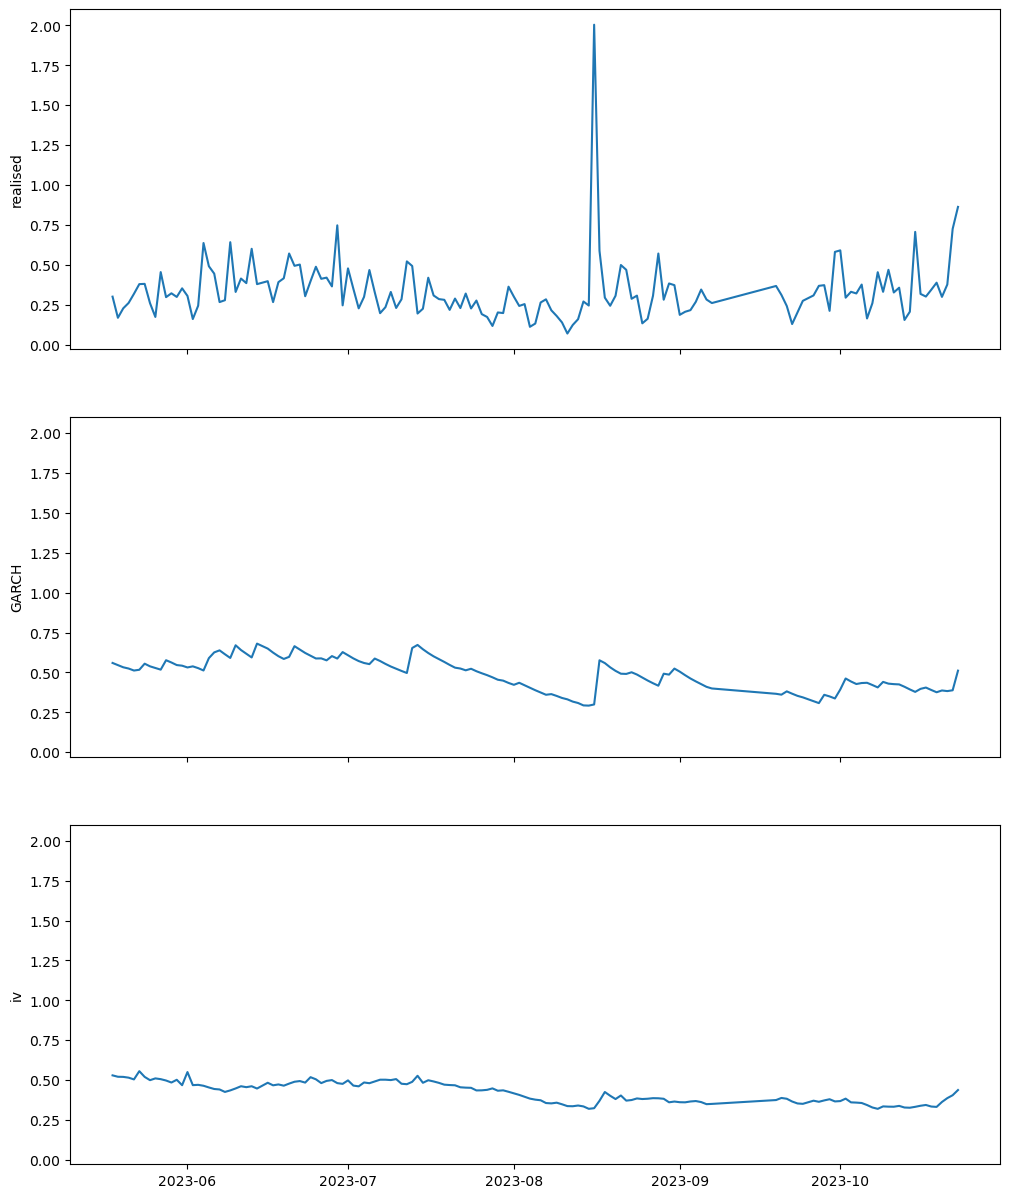

In [76]:
# I plot forward realised volatility, GARCH forecasted volatility, and implied volatility
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12,15), sharey=True, sharex=True)

for i, plot in enumerate(mz_df.columns):
    sns.lineplot(data=mz_df[plot], ax=axes[i])
    
plt.show()

In [77]:
print(f"Maxlags calculation = {4*(146/100)**(2/9):.2f}")

Maxlags calculation = 4.35


The implied volatility series bears a strong resemblance to the GARCH forecast series, suggesting that the results for the Mincer-Zarnowitz regression will be similar. Note that the straight line in September 2023 across all 3 series is due to the missing dates identified above.

I provide the Mincer-Zarnowitz regression results for the GARCH forecasts, IV, and a combination of the two below using Newey-West standard errors with the "maxlags" parameter set to 4 based on a similar calculation as performed previously:

In [78]:
X_garch = sm.add_constant(mz_df[["GARCH"]])
mz_garch = sm.OLS(mz_df["realised"], X_garch).fit(cov_type="HAC", cov_kwds={"maxlags": 4})

print(mz_garch.summary())
print(mz_garch.wald_test("const = 0, GARCH = 1", use_f=False, scalar=False))

                            OLS Regression Results                            
Dep. Variable:               realised   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                    0.1547
Date:                Fri, 12 Jun 2026   Prob (F-statistic):              0.695
Time:                        15:53:35   Log-Likelihood:                 31.755
No. Observations:                 146   AIC:                            -59.51
Df Residuals:                     144   BIC:                            -53.54
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2908      0.133      2.187      0.0

In [79]:
X_iv = sm.add_constant(mz_df[["iv"]])
mz_iv = sm.OLS(mz_df["realised"], X_iv).fit(cov_type="HAC", cov_kwds={"maxlags": 4})

print(mz_iv.summary())
print(mz_iv.wald_test("const = 0, iv = 1", use_f=False, scalar=False))

                            OLS Regression Results                            
Dep. Variable:               realised   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.007
Method:                 Least Squares   F-statistic:                 0.0008211
Date:                Fri, 12 Jun 2026   Prob (F-statistic):              0.977
Time:                        15:53:35   Log-Likelihood:                 31.582
No. Observations:                 146   AIC:                            -59.16
Df Residuals:                     144   BIC:                            -53.20
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3342      0.152      2.206      0.0

In [80]:
X_both = sm.add_constant(mz_df[["GARCH", "iv"]])
mz_both = sm.OLS(mz_df["realised"], X_both).fit(cov_type="HAC", cov_kwds={"maxlags": 4})

print(mz_both.summary())

                            OLS Regression Results                            
Dep. Variable:               realised   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                 -0.008
Method:                 Least Squares   F-statistic:                    0.9290
Date:                Fri, 12 Jun 2026   Prob (F-statistic):              0.397
Time:                        15:53:35   Log-Likelihood:                 31.999
No. Observations:                 146   AIC:                            -58.00
Df Residuals:                     143   BIC:                            -49.05
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3397      0.146      2.334      0.0

All 3 results have near 0 adjusted $R^2$, statistically significant $\alpha$ coefficients, and no statistical significance at even the 10% level for $\beta$ coefficients. Given the minimal difference between regression results for IV and GARCH, I calculate loss-based measures below to compare forecast accuracy. I report mean absolute error (MAE) for comparability with Chi and Hao (2021), since this is the measure they report in their volatility model horserace, and quasi-likelihood (QLIKE) for formal inference. QLIKE is used for inference since it is robust to noise in my realised volatility proxy (Patton, 2011<sup>[6]</sup>), whereas MAE is not robust and is therefore reported for comparability only.

---
<sup>[6]</sup> Patton, A. J. (2011). Volatility forecast comparison using imperfect volatility proxies. *Journal of Econometrics, 160*(1), 246-256.

In [81]:
mae_garch = (mz_df["GARCH"] - mz_df["realised"]).abs().mean()
mae_iv = (mz_df["iv"] - mz_df["realised"]).abs().mean()

ratio_garch = mz_df["realised"]**2 / mz_df["GARCH"]**2
ratio_iv = mz_df["realised"]**2 / mz_df["iv"]**2
qlike_garch = (ratio_garch - np.log(ratio_garch) - 1).mean()
qlike_iv = (ratio_iv - np.log(ratio_iv) - 1).mean()

In [82]:
print(f"GARCH MAE: {mae_garch:.2f}")
print(f"IV MAE: {mae_iv:.2f}\n")
print(f"GARCH QLIKE: {qlike_garch:.2f}")
print(f"IV QLIKE: {qlike_iv:.2f}")

GARCH MAE: 0.21
IV MAE: 0.16

GARCH QLIKE: 0.77
IV QLIKE: 0.62


In [83]:
print(f"IV bias: {(mz_df["iv"] - mz_df["realised"]).mean():.2f}")
print(f"GARCH bias: {(mz_df["GARCH"] - mz_df["realised"]).mean():.2f}")

IV bias: 0.08
GARCH bias: 0.15


Here I define and perform the Diebold-Mariano test (Diebold and Mariano, 1995<sup>[7]</sup>) on the QLIKE scores. The Diebold-Mariano test is a hypothesis test for comparing loss-based measures of forecasting ability. Its null is that there is no difference in the expected forecast accuracy across the sample period. I calculate HAC lags using the same rule of thumb used earlier to account for serial correlation in the loss differential, alongside applying the Harvey-Leybourne-Newbold (1997)<sup>[8]</sup> small sample correction, which is near 1 for 1-step forecasts and included for completeness.

---
<sup>[7]</sup> Diebold, F. X., & Mariano, R. S. (1995). Comparing predictive accuracy. *Journal of Business & Economic Statistics, 13*(3), 253-263.

<sup>[8]</sup> Harvey, D., Leybourne, S. & Newbold, P. (1997). Testing the equality of prediction mean squared errors. *International Journal of Forecasting, 13*(2), 281-291.

In [84]:
def diebold_mariano(loss1, loss2):

    loss_differential = (loss1 - loss2).to_numpy()
    avg_loss_differential = loss_differential.mean()
    demeaned_differential = loss_differential - avg_loss_differential

    n = len(loss1)
    hac_lags = int(4*(n/100)**(2/9))
    lrv = (demeaned_differential ** 2).mean()
    
    for k in range(1, hac_lags+1):
        autocov = (demeaned_differential[k:] * demeaned_differential[:-k]).sum() / n
        lrv += 2 * autocov * (1 - k / (hac_lags+1))
    DM_stat = avg_loss_differential / np.sqrt(lrv/n)

    hln_correction = np.sqrt((n - 1)/n)
    DM_hln = DM_stat * hln_correction

    p_val = 2*(1-stats.t.cdf(np.abs(DM_hln), df=n-1))
    
    return DM_hln, p_val

In [85]:
DM_hln, p_val = diebold_mariano((ratio_garch - np.log(ratio_garch) - 1), (ratio_iv - np.log(ratio_iv) - 1))
print(f"DM test statistic: {DM_hln:.2f}, p-value: {p_val:.2f}")

DM test statistic: 3.56, p-value: 0.00


The QLIKE of IV is lower than that of GARCH, with the results of the Diebold-Mariano test indicating that this difference is statistically significant even at the 1% significance level. The difference is consistent with the smaller bias calculated above (0.08 for IV and 0.15 for GARCH<sup>[9]</sup>). This contrasts the results of Chi and Hao (2021), who found GARCH to provide better forecast accuracy, though given the poor forecasting results of each measure it is possible this is an artefact of the low volatility window over which the models' performance is measured. That hypothesis is consistent with the comparatively stronger performance of the GARCH model forecasts measured over 365 days. Another hypothesis concerns the construction of the IV series as discussed earlier - given the longer horizon for the IV measure, small shocks to short-term volatility expectations will have a muted effect on this IV series, resulting in a smoother curve which converges to volatility expectations plus a volatility risk premium. Over a period of relatively flat volatility, like the main sample period, forward realised volatility hovers around its mean, leading to lower losses for the smoother IV series. Further, given that IV is a forward-looking measure, it is faster to react to changes in regime than GARCH, which is biased by periods of relatively higher volatility in its estimation window.

Given that QLIKE is a measure based on variance ratios and is therefore unit-less, there is some comparability across different windows - though the Diebold-Mariano test cannot be performed across different windows as it requires paired forecasts of the same realisations. I calculate the QLIKE for the 365-day window GARCH model below:

---
<sup>[9]</sup> Note this bias for IV is a rough proxy for the volatility risk premium discussed above given the relatively stable daily realised volatility, though not exact given that VRP would typically be calculated based on horizon-matched IV and forward realised volatility, whereas here the IV horizon is the remaining lifetime of the 29 Dec 2023 option while the forward realised volatility is calculated over one day.

In [86]:
ratio_garch_365 = rv_365**2 / fv_365**2
qlike_garch_365 = (ratio_garch_365 - np.log(ratio_garch_365) - 1).mean()

print(f"GARCH 365 QLIKE: {qlike_garch_365:.2f}")

GARCH 365 QLIKE: 0.61


The QLIKE for the 365-day window GARCH model is lower than that for the shorter window GARCH model and marginally lower than that for the IV, though again I cannot test this difference for statistical significance with the Diebold-Mariano test due to different forecasting windows. The minimal difference in QLIKE between the IV and 365-day GARCH model, despite the large difference in their regression results (i.e. near 0 $R^2$ for IV vs 0.29 for the 365-day GARCH), is driven by the fact that QLIKE measures the proportional accuracy of a model, rather than its ability to explain variation in the data. Unfortunately, due to a lack of data availability, I am not able to produce a similar measure for IV over a longer window for comparison and significance testing.